Sean Bergan

Referring to `Python_exploring_h5ad_files.ipynb` and the [Scanpy Preprocessing and clustering tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html#nearest-neighbor-graph-construction-and-visualization).

**This notebook includes:**
- Reading in h5ad files in our dataset
- Figuring out variable names in our adata and seeing if using ad.concat() + adding a `sample` column, vs. using sc.concat(), affects things downstream
- Exploring adata
- Examining the cell labels in the cell metadata (adata.obs['AIFI_L2']) to see if any labels are underrepresented in any of the drug treatments
     - Visualizing with bar charts and heatmaps
-  Scanpy preprocessing, dimensionality reduction (PCA, UMAPs) and clustering

In [1]:
# Core libraries
import hisepy
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:413: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\frac{1}{m} \\sum_{ij} \\left(A_{ij} - \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/VertexPartition.py:788: SyntaxWarning: invalid escape sequence '\m'
  .. math:: Q = \\sum_{ij} \\left(A_{ij} - \\gamma \\frac{k_i^\mathrm{out} k_j^\mathrm{in}}{m} \\right)\\delta(\\sigma_i, \\sigma_j),
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:27: SyntaxWarning: invalid escape sequence '\g'
  implementation therefore does not guarantee subpartition :math:`\gamma`-density.
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/leidenalg/Optimiser.py:346: SyntaxWarning: invalid escape sequence '\s'
  .. math:: Q = \sum_k \\lambda_k Q_k.


In [2]:
# uuid_list = [
#     '02765813-6130-4fac-8708-f01768aa05b6',
#     '06b73fab-62d2-4fc3-8a86-2df960cbc1ea',
#     '1aecccab-f62a-4c49-b2fe-ba5777930262',
#     '207c5f6c-92ec-4690-a7fd-07b0cbebd9f6',
#     '3adc31cf-1ea9-4a7d-bc63-31358cb8a325',
#     '45e4bd43-4fae-49df-8974-8d043e395f73',
#     '4c13d814-1493-48f8-8021-a819b556e97b',
#     '56bc5070-2968-4c6b-8198-4e997c75e4fe',
#     '64e7735c-e89b-41ef-a293-a39b9ed5ade9',
#     '72755c82-880d-4814-8322-6a81ed07466d',
#     '9693f71c-dcb3-4d40-b2ad-74fc2ad147de',
#     '9f37360e-0191-418b-ab51-fdb86ab9be09',
#     'a3bc4704-5fe3-4a74-bce5-0700689db1f6',
#     'af42c180-0218-4918-ae12-0a4f43c4aa1f',
#     'b790716c-b2de-4028-ad60-1e5a7b81f05d',
#     'bfa4c2f1-69d5-4bcf-a1a6-9beb69dbffc9',
#     'd076758f-3d76-49b7-91be-0217eefcdf26',
#     'd2f8da49-85eb-4dea-a166-5308bb73de91'
# ]

# file_list = hisepy.cache_files(uuid_list)

## Reading in .h5ad file

In [3]:
# old h5ad file without capitalization fixed in clean names
# uuid_list = ['c9cf5bd2-a3a4-4c11-bd4e-ceea1205ec78']

# Updated methodology for reading in adata:

# # old file name upload
# uuid_list = ['a121aba6-89ae-4532-aa37-7e4fcf9b05e4']

uuid_list = ['fa51fd69-eb7c-4bd3-b80a-b8dab2603043']


# have to read it in as a list
files_list = hisepy.cache_files(uuid_list)

print(files_list)
# file list is only one file, so we can just access that for our adata
adata = sc.read_h5ad(files_list[0])

['/home/workspace/input/1742749117/2025_bgmp/fa51fd69-eb7c-4bd3-b80a-b8dab2603043/berkelium-silicon-hydrogen/il6_jak-stat_paired_formulations.h5ad']


## Trying out DEG
Seems we may need to filter our genes first (didn't fix it)

was getting log2 scanpy/numpy errors... those went away after commenting out scale() earlier, but now we have divide by zero errors when using the wilcoxon method.

In [4]:
# making a dictionary of subsetted data where the key is the cell type and the value is the anndata object
subsets_cells = {}

detection_cutoff = 0.02

for cell_type in adata.obs['AIFI_L2'].unique():

    # print(f'current cell type is {cell_type}')
    cell_type_subset = adata[adata.obs.AIFI_L2 == cell_type].copy()

    # filtering out genes that are expressed in too few of cells since they seem to be leading to weird results in DEG
    min_cells = int(cell_type_subset.shape[0] * detection_cutoff)

    sc.pp.filter_genes(
        cell_type_subset,
        min_cells = min_cells
    )
    
    sc.tl.rank_genes_groups(
        adata = cell_type_subset,
        groupby = "clean_drug_name",
        reference = "DMSO control",
        method = "wilcoxon",
        layer = "log_transformed"
    )
    subsets_cells[cell_type] = cell_type_subset

# print(subsets_cells)

# figure out grabbing the data frames from these -- adata.to_df()

# get_rank

In [5]:
# for cell_type, subset_cell in subsets_cells.items():    
#     print(cell_type)
#     sc.pl.rank_genes_groups_dotplot(subset_cell, groupby="drug_name", n_genes=5)

Trying to make sense of the above dot plots, it at first seemed like the columns are repeating information since the reference is only ever the DMSO control. It seems like this is actually picking out the top 5 differentially expressed genes against the reference for each treatment, and is *then* showing the levels those genes are expressed across **all** of the treatments.

## Counts for up/down regulation

In [6]:
# tracking all gene names that are up/down regulated in any cell
up_across_cells = set()
down_across_cells = set()

# add in grouping by drug
# plot as bar plot or heat map

def graph_diff_gene_counts_with_agreement(lfc_threshold):
    # initialize the dataframe
    all_cells_sig_genes = pd.DataFrame({'cell_type':[], 'names': [], 'regulation_dir': []})

    deg_df_list = []

    reg_counts_list = []
    
    for cell_type, subset_cell in subsets_cells.items():
        print("================================")
        print(cell_type)
        print("================================")
        cell_df = sc.get.rank_genes_groups_df(subset_cell, group=None)

        cell_df['cell_type'] = cell_type

        deg_df_list.append(cell_df)

        print(cell_df)

        print("================================")
        
        # make a column that is absolute value of logfold change
        cell_df['abs_logfoldchanges'] = cell_df['logfoldchanges'].abs()
    
        # filter for absolute value of log fold change > 1 and adjusted p values less than 0.05
        sig_diff = cell_df[(cell_df['pvals_adj'] < 0.05) & (cell_df['abs_logfoldchanges'] > lfc_threshold)].sort_values(by = 'abs_logfoldchanges', ascending = False)
    
        # add a categorical variable showing up or down regulation
        sig_diff['regulation_dir'] = np.where(sig_diff['logfoldchanges'] > 0, 'Up', 'Down')
        # print(sig_diff.head())

        # get sets of each of the genes up/down in IL6 to plot agreement counts within the graph
        up_in_il6 = set(sig_diff.loc[((sig_diff['group'] == 'IL-6 control') & (sig_diff['regulation_dir'] == 'Up')), 'names'])
        down_in_il6 = set(sig_diff.loc[((sig_diff['group'] == 'IL-6 control') & (sig_diff['regulation_dir'] == 'Down')), 'names'])

        # print(up_in_il6)
        # print(down_in_il6)
        
        # making the dataframe that agrees with IL6:
        agreeing_df = sig_diff[((sig_diff['regulation_dir'] == 'Up') & (sig_diff['names'].isin(up_in_il6))) | \
            ((sig_diff['regulation_dir'] == 'Down') & (sig_diff['names'].isin(down_in_il6)))]
        
        # print(agreeing_df)
        
        counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
        # same thing but only the agreeing data
        agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


        print("================================")
        print("Counts by treatment:")
        print("================================")
        print(counts_by_treatment)
        print("================================")

        counts_by_treatment["cell_type"] = cell_type
        reg_counts_list.append(counts_by_treatment)

        
        # these others were ugly/unclear
        # disagreeing_colors = {'Up': '#B27C4F', 'Down': '#3D5979'}
        # disagreeing_colors = {'Up': '#C28C5F', 'Down': '#4D6989'}

        # lighter and less intense than the default colors, but enough contrast
        disagreeing_colors = {'Down': '#4eb9ff', 'Up': '#ffcd7c'}

        # print(sns.color_palette())

        # # this didn't work
        # # default seaborn colors but doing this to force staggeringabs
        # agreeing_colors = {'Down': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
        #                    'Up': (1.0, 0.4980392156862745, 0.054901960784313725)}

        agreeing_counts_by_treatment['regulation_dir'] = agreeing_counts_by_treatment['regulation_dir'].astype(str) + ' (shared with IL-6)'
        
        plt.figure(figsize = (12, 5))
        bar_width = 0.5
        # x-axis is cell type labels AIFI_L2, y-axis is count, hue (grouping by) drug_name
        sns.barplot(data = counts_by_treatment, 
                    x = "group", 
                    y = "count", 
                    hue = "regulation_dir", 
                    palette = disagreeing_colors, 
                    dodge = True)
        
        # layer the agreeing data over the top of the other data to make custom stacked bar plot
        # hard coding this if statement because I can't get the general fix figured out
        # in time for the presentation tomorrow:
        sns.barplot(data = agreeing_counts_by_treatment, 
                    x = "group", 
                    y = "count", 
                    hue = "regulation_dir",
                    dodge = True)
        
        plt.xticks(rotation = 45, ha = 'right')
        if "Naive" in cell_type:
            plot_title = f"{cell_type} (IL-6 Responsive)"
        elif "Effector" in cell_type:
            plot_title = f"{cell_type} (IL-6 Nonresponsive)"
        else:
            plot_title = cell_type
        plt.title(plot_title, fontsize = 20)
        plt.xlabel("Treatment", fontsize = 15)
        plt.ylabel("DEG Counts", fontsize = 15)
        
        #moving the legend to be outside of the plot
        plt.legend(title="Regulation direction", fontsize = 12, title_fontsize = 12)
        plt.tight_layout()
        file_name = f'figures/reg_counts_{cell_type}_threshold_{lfc_threshold}'.replace('.', '_').replace(' ', '_') + '.svg'
        plt.savefig(file_name, transparent = True)
        plt.show()
    
        # print(sig_diff.groupby('regulation')['regulation'].count())
        # concatenating these to our data frame across all cell types with a label for what the cell type is
        # also making it unique so we don't have duplicate counts across different treatment types
        all_cells_sig_genes = pd.concat([all_cells_sig_genes, sig_diff[['cell_type', 'names', 'regulation_dir']]]).drop_duplicates()
    
    print("================================")
    print("All cells")
    print("================================")
    regulation_counts = all_cells_sig_genes.groupby(['cell_type', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
    print(regulation_counts)
    
    # TODO: reorder the treatments so IL-6 control is on the left?
    
    # bar plot:
    print(all_cells_sig_genes[['names', 'regulation_dir']].drop_duplicates().groupby('regulation_dir').count())
    
    plt.figure(figsize = (12, 5))
    #x-axis is cell type labels AIFI_L2, y-axis is count, hue (grouping by) drug_name
    sns.barplot(data = regulation_counts, x = "cell_type", y = "count", hue = "regulation_dir")
    plt.xticks(rotation = 90)
    plt.xlabel("Cell type label (AIFI_L2)")
    plt.ylabel("Count")
    
    # moving the legend to be outside of the plot

    plt.legend(title="Regulation direction")
    plt.tight_layout()
    plt.show()

    # now making concatenated dataframes to upload for interactive visualizations
    concat_deg = pd.concat(deg_df_list)
    print(concat_deg)
    concat_deg.to_csv('wilcoxon_deg_results.csv')

    concat_reg_counts = pd.concat(reg_counts_list)
    concat_reg_counts.to_csv(f'wilcoxon_deg_counts_logfc_{lfc_threshold}.csv')


In [7]:
# tracking all gene names that are up/down regulated in any cell
up_across_cells = set()
down_across_cells = set()

# add in grouping by drug
# plot as bar plot or heat map


def graph_diff_gene_counts(lfc_threshold):
    # initialize the dataframe
    all_cells_sig_genes = pd.DataFrame({'cell_type':[], 'names': [], 'regulation_dir': []})
    
    for cell_type, subset_cell in subsets_cells.items():
        print("================================")
        print(cell_type)
        print("================================")
        cell_df = sc.get.rank_genes_groups_df(subset_cell, group=None)
    
        # make a column that is absolute value of logfold change
        cell_df['abs_logfoldchanges'] = cell_df['logfoldchanges'].abs()
    
        # filter for absolute value of log fold change > 1 and adjusted p values less than 0.05
        sig_diff = cell_df[(cell_df['pvals_adj'] < 0.05) & (cell_df['abs_logfoldchanges'] > lfc_threshold)].sort_values(by = 'abs_logfoldchanges', ascending = False)
    
        # add a categorical variable showing up or down regulation
        sig_diff['regulation_dir'] = np.where(sig_diff['logfoldchanges'] > 0, 'Up', 'Down')
        sig_diff['cell_type'] = cell_type
        # print(sig_diff.head())
    
        
        counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
        plt.figure(figsize = (12, 6))
        #x-axis is cell type labels AIFI_L2, y-axis is count, hue (grouping by) drug_name
        sns.barplot(data = counts_by_treatment, x = "group", y = "count", hue = "regulation_dir")
        plt.xticks(rotation = 90)
        plt.title(cell_type)
        plt.xlabel("Treatment")
        plt.ylabel("Count")
        
        #moving the legend to be outside of the plot
        plt.legend(title="Regulation direction", bbox_to_anchor=(1.05, 1))
        plt.tight_layout()
        file_name = f'{cell_type}_threshold_{lfc_threshold}'.replace('.', '_').replace(' ', '_') + '.svg'
        plt.savefig(file_name)
        plt.show()
    
        # print(sig_diff.groupby('regulation')['regulation'].count())
        # concatenating these to our data frame across all cell types with a label for what the cell type is
        # also making it unique so we don't have duplicate counts across different treatment types
        all_cells_sig_genes = pd.concat([all_cells_sig_genes, sig_diff[['cell_type', 'names', 'regulation_dir']]]).drop_duplicates()
    
    print("================================")
    print("All cells")
    print("================================")
    regulation_counts = all_cells_sig_genes.groupby(['cell_type', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
    print(regulation_counts)
    
    #todo: reorder the treatments
    
    # bar plot:
    print(all_cells_sig_genes[['names', 'regulation_dir']].drop_duplicates().groupby('regulation_dir').count())
    
    plt.figure(figsize = (12, 6))
    #x-axis is cell type labels AIFI_L2, y-axis is count, hue (grouping by) drug_name
    sns.barplot(data = regulation_counts, x = "cell_type", y = "count", hue = "regulation_dir")
    plt.xticks(rotation = 90)
    plt.xlabel("Cell type label (AIFI_L2)")
    plt.ylabel("Count")
    
    #moving the legend to be outside of the plot
    plt.legend(title="Regulation direction", bbox_to_anchor=(1.05, 1))
    plt.tight_layout()
    plt.show()


CD4 Central Memory
              group  names     scores  logfoldchanges          pvals  \
0      IL-6 control  SBNO2  60.260761        2.309811   0.000000e+00   
1      IL-6 control  IKZF1  39.254021        0.647633   0.000000e+00   
2      IL-6 control  IL2RB  38.148853        1.983307   0.000000e+00   
3      IL-6 control  IFI16  36.474274        0.743574  2.837282e-291   
4      IL-6 control  STAT3  36.020184        1.292323  4.041929e-284   
...             ...    ...        ...             ...            ...   
21415   Tofacitinib    B2M -10.280299       -0.039850   8.645908e-25   
21416   Tofacitinib   TAP1 -13.433199       -0.263474   3.863559e-41   
21417   Tofacitinib  NLRC5 -15.681939       -0.537971   2.010212e-55   
21418   Tofacitinib   IRF1 -16.673597       -0.739395   2.039434e-62   
21419   Tofacitinib  STAT1 -24.045490       -1.806728  9.305630e-128   

           pvals_adj           cell_type  
0       0.000000e+00  CD4 Central Memory  
1       0.000000e+00  CD4 Cent

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


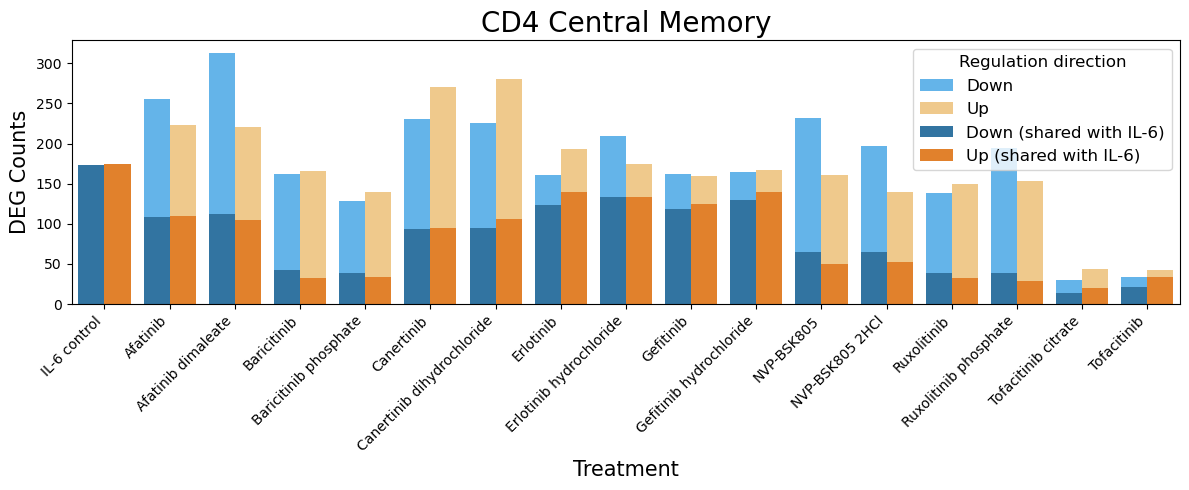

CD8 Naive
              group   names     scores  logfoldchanges          pvals  \
0      IL-6 control   SBNO2  66.217400        3.002756   0.000000e+00   
1      IL-6 control   IFI16  56.620872        2.117367   0.000000e+00   
2      IL-6 control  NOTCH1  43.235703        2.998714   0.000000e+00   
3      IL-6 control   IL2RB  43.174217        2.989676   0.000000e+00   
4      IL-6 control   IKZF1  42.416176        0.461965   0.000000e+00   
...             ...     ...        ...             ...            ...   
20140   Tofacitinib   PSMB9 -15.270100       -0.919560   1.209882e-52   
20141   Tofacitinib   NLRC5 -21.409925       -0.442889  1.079853e-101   
20142   Tofacitinib    TAP1 -21.560272       -0.398712  4.241127e-103   
20143   Tofacitinib    IRF1 -32.694782       -1.857694  1.852633e-234   
20144   Tofacitinib   STAT1 -38.419399       -3.107304   0.000000e+00   

           pvals_adj  cell_type  
0       0.000000e+00  CD8 Naive  
1       0.000000e+00  CD8 Naive  
2       0.0

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


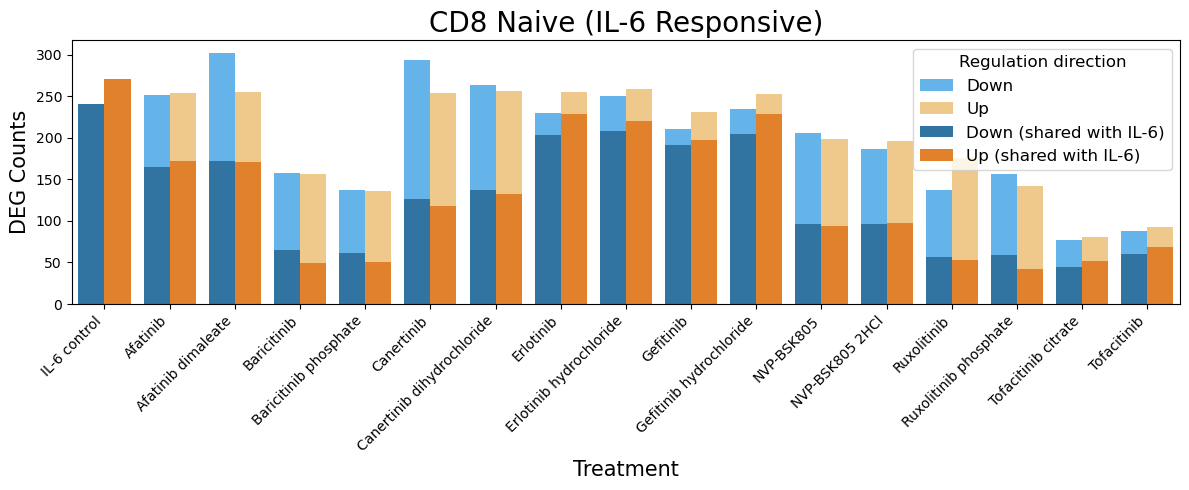

CD4 Naive
              group  names     scores  logfoldchanges          pvals  \
0      IL-6 control  SBNO2  87.684273        2.757730   0.000000e+00   
1      IL-6 control  IFI16  67.603401        1.868780   0.000000e+00   
2      IL-6 control    ITK  60.595070        0.844253   0.000000e+00   
3      IL-6 control  IKZF1  59.206924        0.388137   0.000000e+00   
4      IL-6 control    MYC  57.937393        2.773212   0.000000e+00   
...             ...    ...        ...             ...            ...   
19919   Tofacitinib   FYB1 -23.221106       -0.273561  2.787213e-119   
19920   Tofacitinib   TAP1 -28.115496       -0.584592  6.333645e-174   
19921   Tofacitinib  NLRC5 -31.913134       -0.754117  1.755265e-223   
19922   Tofacitinib   IRF1 -38.514675       -1.689848   0.000000e+00   
19923   Tofacitinib  STAT1 -48.421734       -2.891609   0.000000e+00   

           pvals_adj  cell_type  
0       0.000000e+00  CD4 Naive  
1       0.000000e+00  CD4 Naive  
2       0.000000e+00  C

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


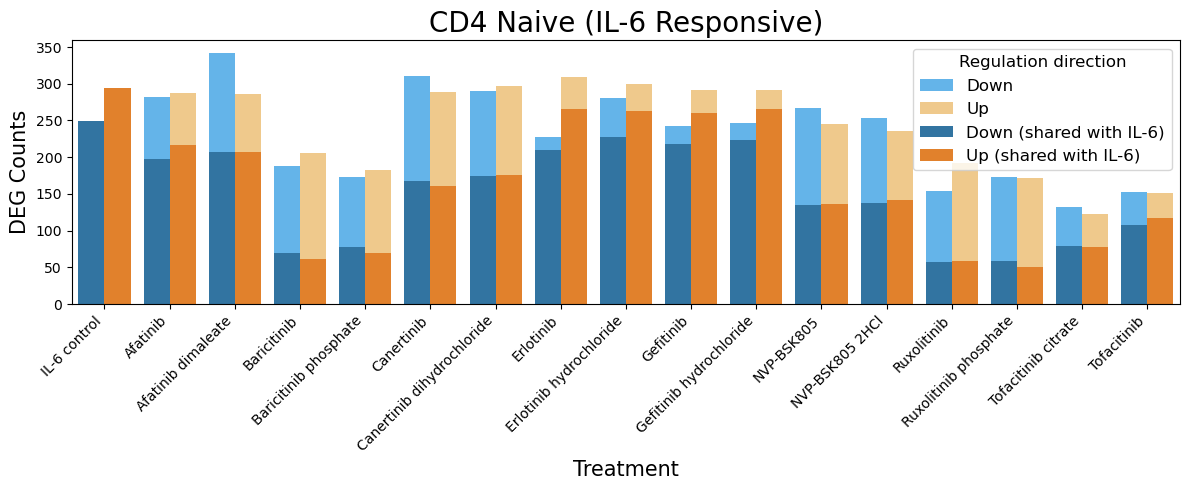

Treg
              group  names     scores  logfoldchanges          pvals  \
0      IL-6 control  SBNO2  34.536629        2.885511  2.263102e-261   
1      IL-6 control  IL2RA  26.933683        2.784782  8.858941e-160   
2      IL-6 control  IKZF1  22.091831        0.679619  3.787295e-108   
3      IL-6 control  IFI16  21.339336        1.191878  4.898559e-101   
4      IL-6 control   BATF  19.946379        2.844364   1.611437e-88   
...             ...    ...        ...             ...            ...   
20140   Tofacitinib  PSMB9  -6.829497       -0.874956   8.521258e-12   
20141   Tofacitinib   TAP1  -8.783854       -0.399071   1.579671e-18   
20142   Tofacitinib  NLRC5 -11.185884       -0.650137   4.781133e-29   
20143   Tofacitinib   IRF1 -14.481407       -1.376393   1.588118e-47   
20144   Tofacitinib  STAT1 -18.152842       -2.891810   1.219251e-73   

           pvals_adj cell_type  
0      2.681776e-258      Treg  
1      5.248923e-157      Treg  
2      1.495982e-105      Treg 

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


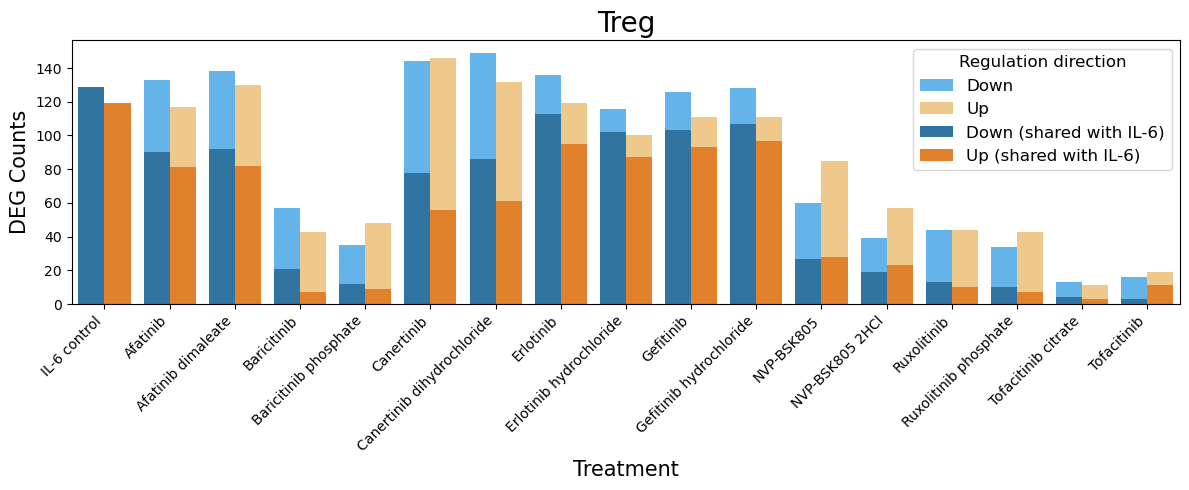

CD8 Central Memory
              group  names     scores  logfoldchanges         pvals  \
0      IL-6 control  SBNO2  15.921474        1.465850  4.496608e-57   
1      IL-6 control  IFI16  10.609028        0.767661  2.705488e-26   
2      IL-6 control  STAT3   8.690569        0.586200  3.606303e-18   
3      IL-6 control   JAK3   8.085828        0.984734  6.174357e-16   
4      IL-6 control  IKZF1   7.907516        0.503086  2.625753e-15   
...             ...    ...        ...             ...           ...   
21211   Tofacitinib  TXNIP  -4.064066       -0.413599  4.822521e-05   
21212   Tofacitinib  PSMB9  -4.553599       -0.584715  5.273574e-06   
21213   Tofacitinib  NLRC5  -4.910101       -0.331340  9.102955e-07   
21214   Tofacitinib  STAT1  -7.254548       -1.344640  4.030056e-13   
21215   Tofacitinib   IRF1  -7.515410       -0.772093  5.673283e-14   

          pvals_adj           cell_type  
0      5.611767e-54  CD8 Central Memory  
1      1.688225e-23  CD8 Central Memory  
2 

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


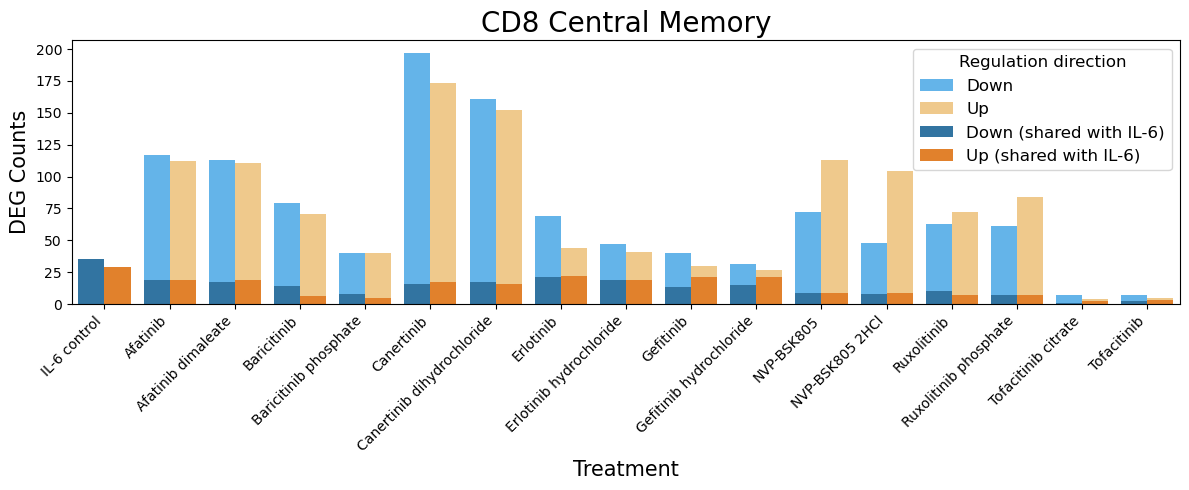

CD4 Effector Memory
              group   names    scores  logfoldchanges         pvals  \
0      IL-6 control   SBNO2  3.028312        0.308693  2.459242e-03   
1      IL-6 control  PSMB10  2.443950        0.303908  1.452742e-02   
2      IL-6 control    BATF  2.103480        0.310279  3.542387e-02   
3      IL-6 control   KEAP1  2.052100        0.357575  4.015990e-02   
4      IL-6 control  NUP107  1.866208        0.370227  6.201225e-02   
...             ...     ...       ...             ...           ...   
20463   Tofacitinib     LAT -3.710526       -0.273370  2.068286e-04   
20464   Tofacitinib     B2M -5.299791       -0.028143  1.159353e-07   
20465   Tofacitinib   STAT1 -5.516691       -0.456747  3.454421e-08   
20466   Tofacitinib   NLRC5 -6.057477       -0.173460  1.382727e-09   
20467   Tofacitinib   TXNIP -7.025540       -0.376274  2.132403e-12   

          pvals_adj            cell_type  
0      5.287369e-02  CD4 Effector Memory  
1      1.784797e-01  CD4 Effector Memory 

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


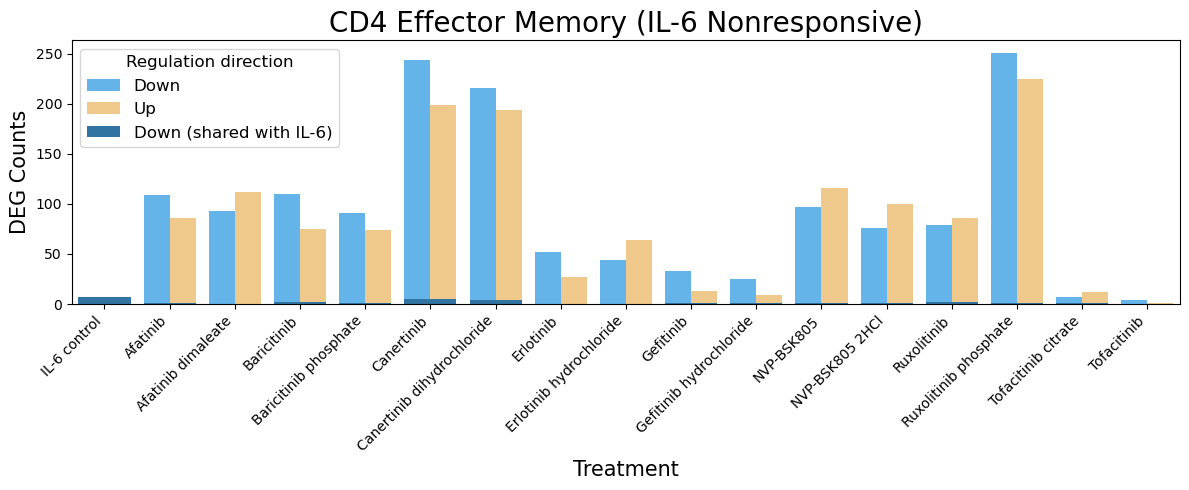

MAIT
              group   names    scores  logfoldchanges     pvals  pvals_adj  \
0      IL-6 control   SBNO2  2.669501        0.548107  0.007596   0.999799   
1      IL-6 control   NISCH  2.271718        0.721830  0.023104   0.999799   
2      IL-6 control    USP1  2.183334        0.447095  0.029011   0.999799   
3      IL-6 control     MAF  2.111663        0.440785  0.034715   0.999799   
4      IL-6 control   PRDM1  2.057409        0.421682  0.039647   0.999799   
...             ...     ...       ...             ...       ...        ...   
21466   Tofacitinib    CD37 -2.215544       -0.249159  0.026723   0.999910   
21467   Tofacitinib   STAT3 -2.345055       -0.322721  0.019024   0.999910   
21468   Tofacitinib   EOMES -2.397693       -0.448040  0.016499   0.999910   
21469   Tofacitinib   CYTH1 -2.567218       -0.239146  0.010252   0.999910   
21470   Tofacitinib  SQSTM1 -2.698645       -0.128130  0.006962   0.999910   

      cell_type  
0          MAIT  
1          MAIT  
2   

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


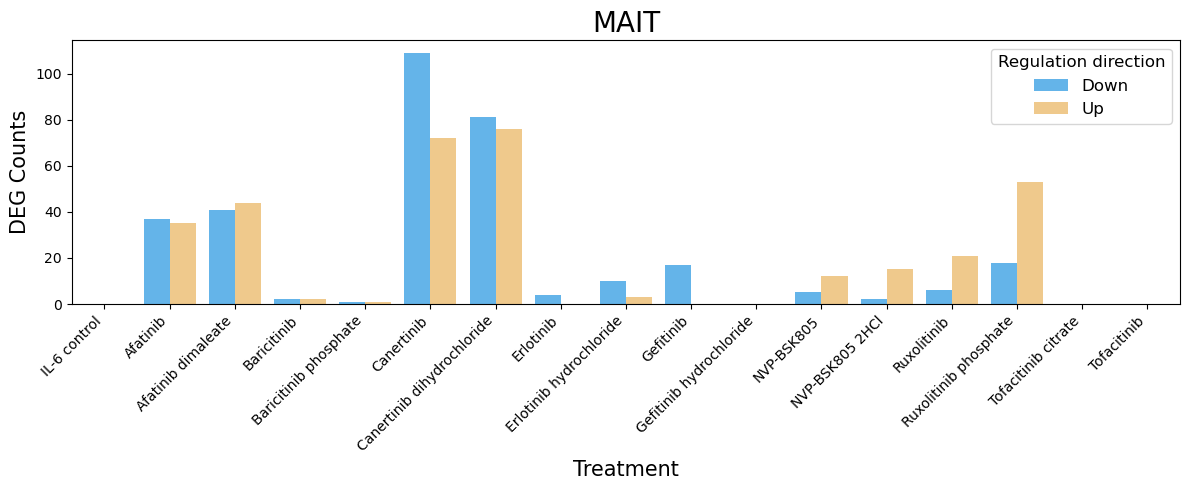

CD8 Effector Memory
              group   names    scores  logfoldchanges         pvals  \
0      IL-6 control   SBNO2  2.921534        0.344564  3.483128e-03   
1      IL-6 control    IRF4  2.806548        0.329614  5.007548e-03   
2      IL-6 control  LGALS8  2.415901        0.320705  1.569634e-02   
3      IL-6 control  TXNRD1  2.330785        0.281291  1.976472e-02   
4      IL-6 control    KTN1  2.297100        0.264253  2.161310e-02   
...             ...     ...       ...             ...           ...   
21092   Tofacitinib   PSMB9 -4.004116       -0.302400  6.224977e-05   
21093   Tofacitinib    CD52 -4.127452       -0.183443  3.668054e-05   
21094   Tofacitinib   TAPBP -4.517295       -0.058447  6.263446e-06   
21095   Tofacitinib   TXNIP -4.760663       -0.377442  1.929586e-06   
21096   Tofacitinib     B2M -5.372494       -0.030784  7.765502e-08   

       pvals_adj            cell_type  
0       0.270160  CD8 Effector Memory  
1       0.326991  CD8 Effector Memory  
2      

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


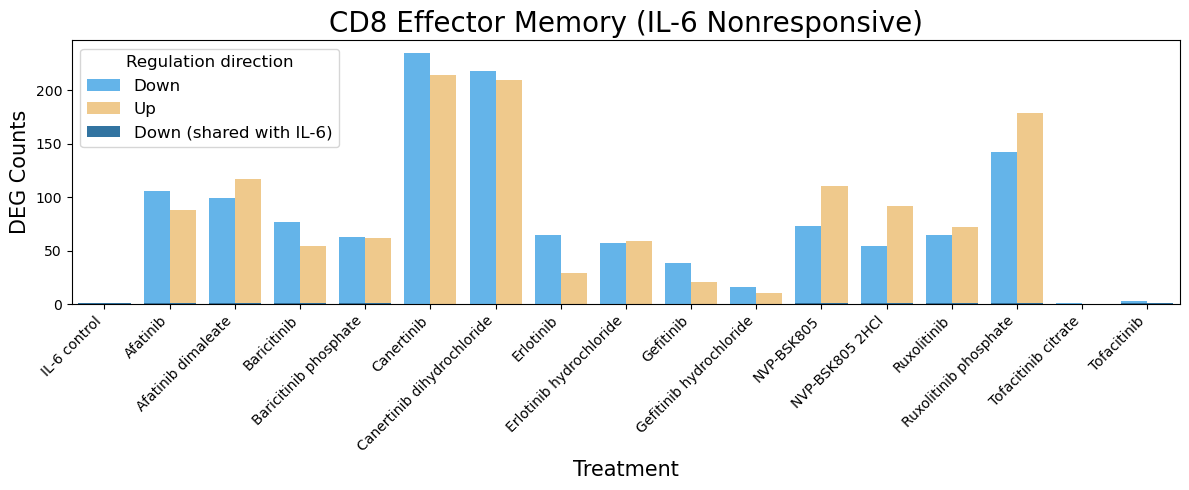

All cells
              cell_type regulation_dir  count
0    CD4 Central Memory           Down    614
1    CD4 Central Memory             Up    563
2   CD4 Effector Memory           Down    514
3   CD4 Effector Memory             Up    456
4             CD4 Naive           Down    587
5             CD4 Naive             Up    629
6    CD8 Central Memory           Down    337
7    CD8 Central Memory             Up    334
8   CD8 Effector Memory           Down    417
9   CD8 Effector Memory             Up    431
10            CD8 Naive           Down    578
11            CD8 Naive             Up    592
12                 MAIT           Down    151
13                 MAIT             Up    163
14                 Treg           Down    280
15                 Treg             Up    290
                names
regulation_dir       
Down              881
Up                908


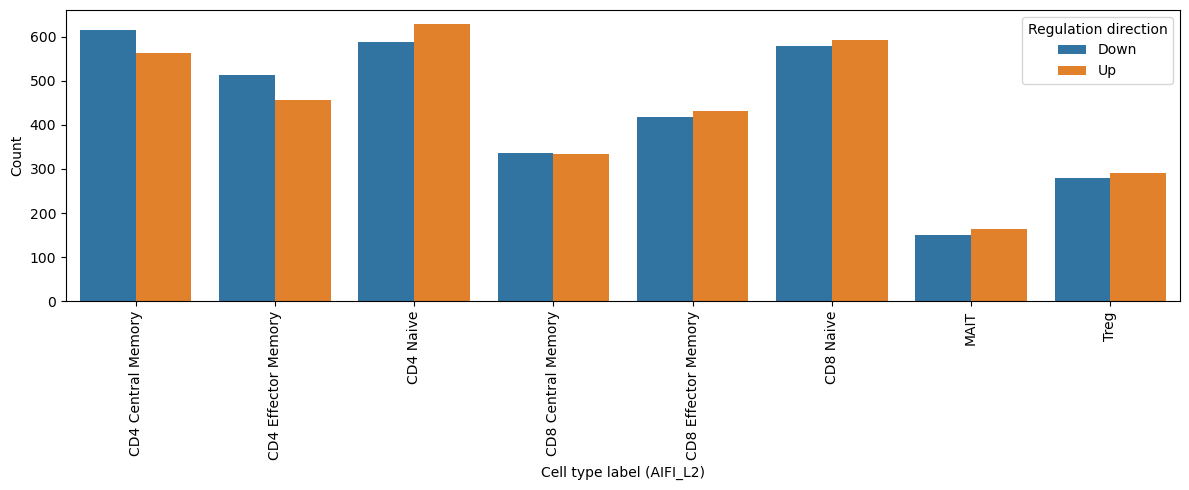

              group  names     scores  logfoldchanges          pvals  \
0      IL-6 control  SBNO2  60.260761        2.309811   0.000000e+00   
1      IL-6 control  IKZF1  39.254021        0.647633   0.000000e+00   
2      IL-6 control  IL2RB  38.148853        1.983307   0.000000e+00   
3      IL-6 control  IFI16  36.474274        0.743574  2.837282e-291   
4      IL-6 control  STAT3  36.020184        1.292323  4.041929e-284   
...             ...    ...        ...             ...            ...   
21092   Tofacitinib  PSMB9  -4.004116       -0.302400   6.224977e-05   
21093   Tofacitinib   CD52  -4.127452       -0.183443   3.668054e-05   
21094   Tofacitinib  TAPBP  -4.517295       -0.058447   6.263446e-06   
21095   Tofacitinib  TXNIP  -4.760663       -0.377442   1.929586e-06   
21096   Tofacitinib    B2M  -5.372494       -0.030784   7.765502e-08   

           pvals_adj            cell_type  abs_logfoldchanges  
0       0.000000e+00   CD4 Central Memory            2.309811  
1      

In [8]:
graph_diff_gene_counts_with_agreement(lfc_threshold = 0.1)

CD4 Central Memory
              group  names     scores  logfoldchanges          pvals  \
0      IL-6 control  SBNO2  60.260761        2.309811   0.000000e+00   
1      IL-6 control  IKZF1  39.254021        0.647633   0.000000e+00   
2      IL-6 control  IL2RB  38.148853        1.983307   0.000000e+00   
3      IL-6 control  IFI16  36.474274        0.743574  2.837282e-291   
4      IL-6 control  STAT3  36.020184        1.292323  4.041929e-284   
...             ...    ...        ...             ...            ...   
21415   Tofacitinib    B2M -10.280299       -0.039850   8.645908e-25   
21416   Tofacitinib   TAP1 -13.433199       -0.263474   3.863559e-41   
21417   Tofacitinib  NLRC5 -15.681939       -0.537971   2.010212e-55   
21418   Tofacitinib   IRF1 -16.673597       -0.739395   2.039434e-62   
21419   Tofacitinib  STAT1 -24.045490       -1.806728  9.305630e-128   

           pvals_adj           cell_type  
0       0.000000e+00  CD4 Central Memory  
1       0.000000e+00  CD4 Cent

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


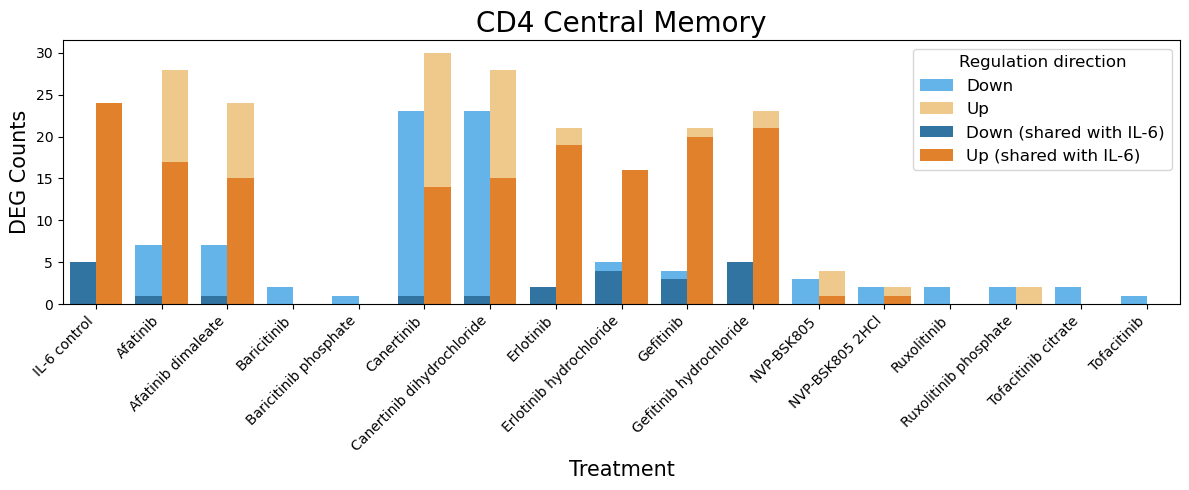

CD8 Naive
              group   names     scores  logfoldchanges          pvals  \
0      IL-6 control   SBNO2  66.217400        3.002756   0.000000e+00   
1      IL-6 control   IFI16  56.620872        2.117367   0.000000e+00   
2      IL-6 control  NOTCH1  43.235703        2.998714   0.000000e+00   
3      IL-6 control   IL2RB  43.174217        2.989676   0.000000e+00   
4      IL-6 control   IKZF1  42.416176        0.461965   0.000000e+00   
...             ...     ...        ...             ...            ...   
20140   Tofacitinib   PSMB9 -15.270100       -0.919560   1.209882e-52   
20141   Tofacitinib   NLRC5 -21.409925       -0.442889  1.079853e-101   
20142   Tofacitinib    TAP1 -21.560272       -0.398712  4.241127e-103   
20143   Tofacitinib    IRF1 -32.694782       -1.857694  1.852633e-234   
20144   Tofacitinib   STAT1 -38.419399       -3.107304   0.000000e+00   

           pvals_adj  cell_type  
0       0.000000e+00  CD8 Naive  
1       0.000000e+00  CD8 Naive  
2       0.0

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


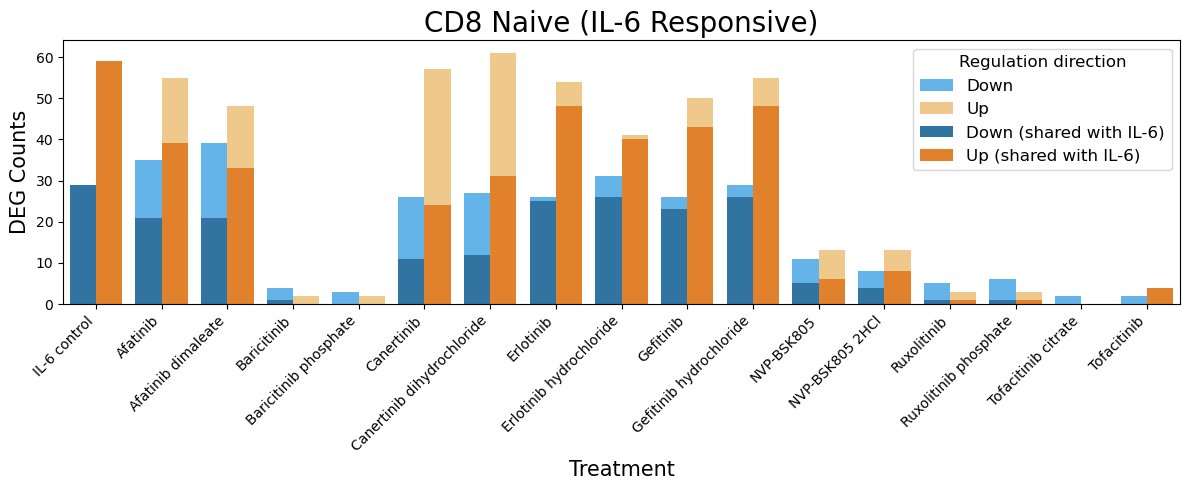

CD4 Naive
              group  names     scores  logfoldchanges          pvals  \
0      IL-6 control  SBNO2  87.684273        2.757730   0.000000e+00   
1      IL-6 control  IFI16  67.603401        1.868780   0.000000e+00   
2      IL-6 control    ITK  60.595070        0.844253   0.000000e+00   
3      IL-6 control  IKZF1  59.206924        0.388137   0.000000e+00   
4      IL-6 control    MYC  57.937393        2.773212   0.000000e+00   
...             ...    ...        ...             ...            ...   
19919   Tofacitinib   FYB1 -23.221106       -0.273561  2.787213e-119   
19920   Tofacitinib   TAP1 -28.115496       -0.584592  6.333645e-174   
19921   Tofacitinib  NLRC5 -31.913134       -0.754117  1.755265e-223   
19922   Tofacitinib   IRF1 -38.514675       -1.689848   0.000000e+00   
19923   Tofacitinib  STAT1 -48.421734       -2.891609   0.000000e+00   

           pvals_adj  cell_type  
0       0.000000e+00  CD4 Naive  
1       0.000000e+00  CD4 Naive  
2       0.000000e+00  C

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


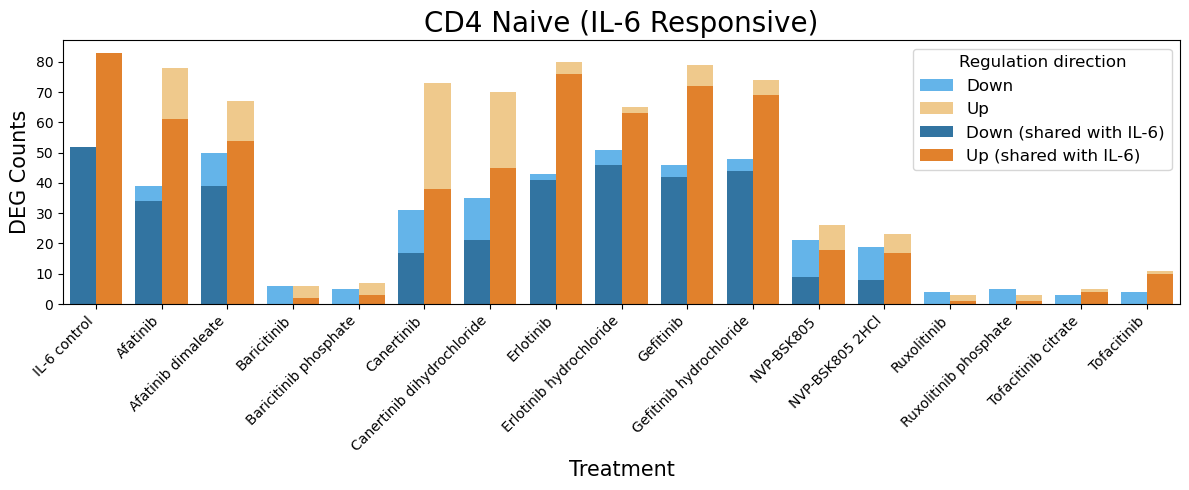

Treg
              group  names     scores  logfoldchanges          pvals  \
0      IL-6 control  SBNO2  34.536629        2.885511  2.263102e-261   
1      IL-6 control  IL2RA  26.933683        2.784782  8.858941e-160   
2      IL-6 control  IKZF1  22.091831        0.679619  3.787295e-108   
3      IL-6 control  IFI16  21.339336        1.191878  4.898559e-101   
4      IL-6 control   BATF  19.946379        2.844364   1.611437e-88   
...             ...    ...        ...             ...            ...   
20140   Tofacitinib  PSMB9  -6.829497       -0.874956   8.521258e-12   
20141   Tofacitinib   TAP1  -8.783854       -0.399071   1.579671e-18   
20142   Tofacitinib  NLRC5 -11.185884       -0.650137   4.781133e-29   
20143   Tofacitinib   IRF1 -14.481407       -1.376393   1.588118e-47   
20144   Tofacitinib  STAT1 -18.152842       -2.891810   1.219251e-73   

           pvals_adj cell_type  
0      2.681776e-258      Treg  
1      5.248923e-157      Treg  
2      1.495982e-105      Treg 

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


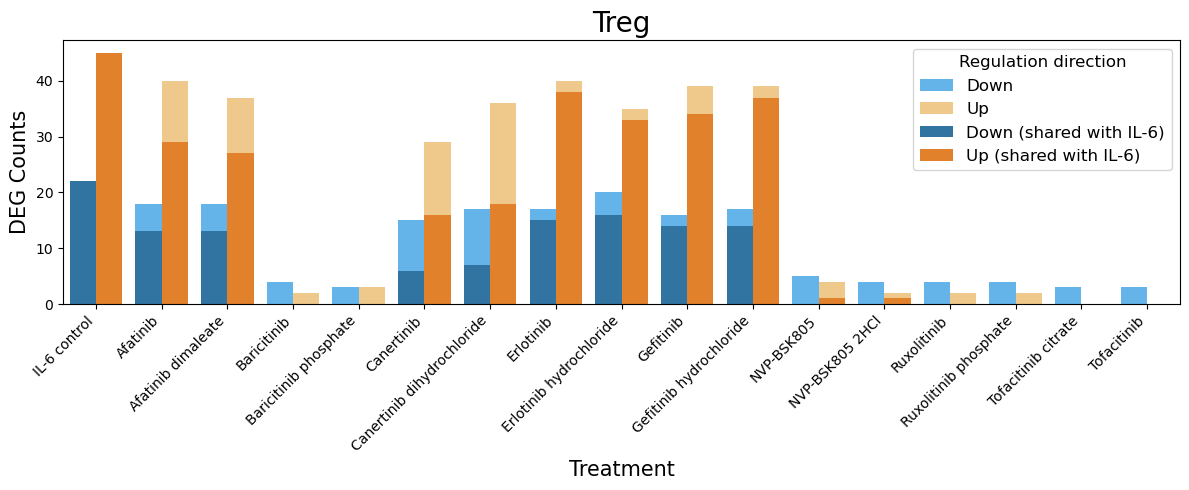

CD8 Central Memory
              group  names     scores  logfoldchanges         pvals  \
0      IL-6 control  SBNO2  15.921474        1.465850  4.496608e-57   
1      IL-6 control  IFI16  10.609028        0.767661  2.705488e-26   
2      IL-6 control  STAT3   8.690569        0.586200  3.606303e-18   
3      IL-6 control   JAK3   8.085828        0.984734  6.174357e-16   
4      IL-6 control  IKZF1   7.907516        0.503086  2.625753e-15   
...             ...    ...        ...             ...           ...   
21211   Tofacitinib  TXNIP  -4.064066       -0.413599  4.822521e-05   
21212   Tofacitinib  PSMB9  -4.553599       -0.584715  5.273574e-06   
21213   Tofacitinib  NLRC5  -4.910101       -0.331340  9.102955e-07   
21214   Tofacitinib  STAT1  -7.254548       -1.344640  4.030056e-13   
21215   Tofacitinib   IRF1  -7.515410       -0.772093  5.673283e-14   

          pvals_adj           cell_type  
0      5.611767e-54  CD8 Central Memory  
1      1.688225e-23  CD8 Central Memory  
2 

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


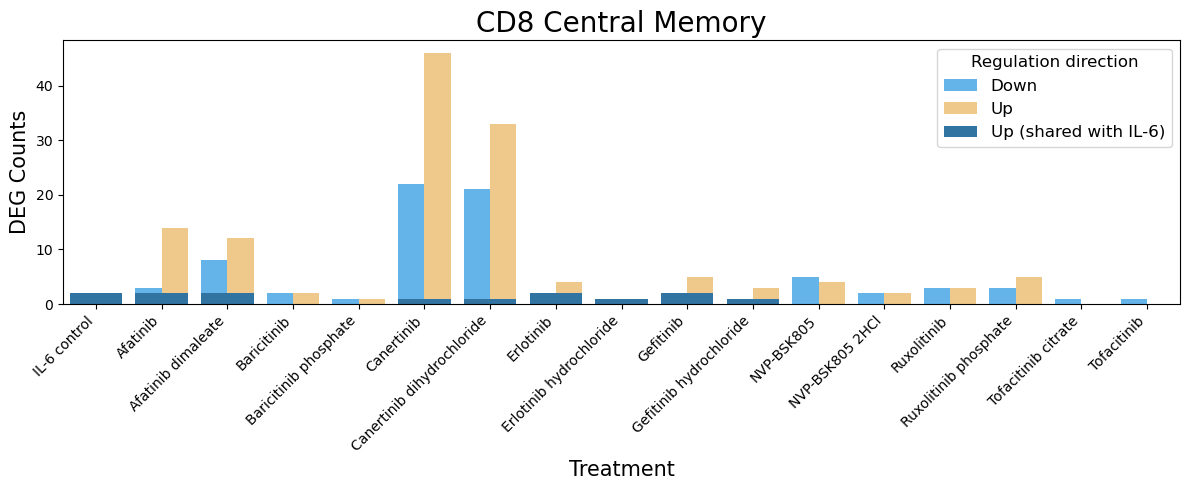

CD4 Effector Memory
              group   names    scores  logfoldchanges         pvals  \
0      IL-6 control   SBNO2  3.028312        0.308693  2.459242e-03   
1      IL-6 control  PSMB10  2.443950        0.303908  1.452742e-02   
2      IL-6 control    BATF  2.103480        0.310279  3.542387e-02   
3      IL-6 control   KEAP1  2.052100        0.357575  4.015990e-02   
4      IL-6 control  NUP107  1.866208        0.370227  6.201225e-02   
...             ...     ...       ...             ...           ...   
20463   Tofacitinib     LAT -3.710526       -0.273370  2.068286e-04   
20464   Tofacitinib     B2M -5.299791       -0.028143  1.159353e-07   
20465   Tofacitinib   STAT1 -5.516691       -0.456747  3.454421e-08   
20466   Tofacitinib   NLRC5 -6.057477       -0.173460  1.382727e-09   
20467   Tofacitinib   TXNIP -7.025540       -0.376274  2.132403e-12   

          pvals_adj            cell_type  
0      5.287369e-02  CD4 Effector Memory  
1      1.784797e-01  CD4 Effector Memory 

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


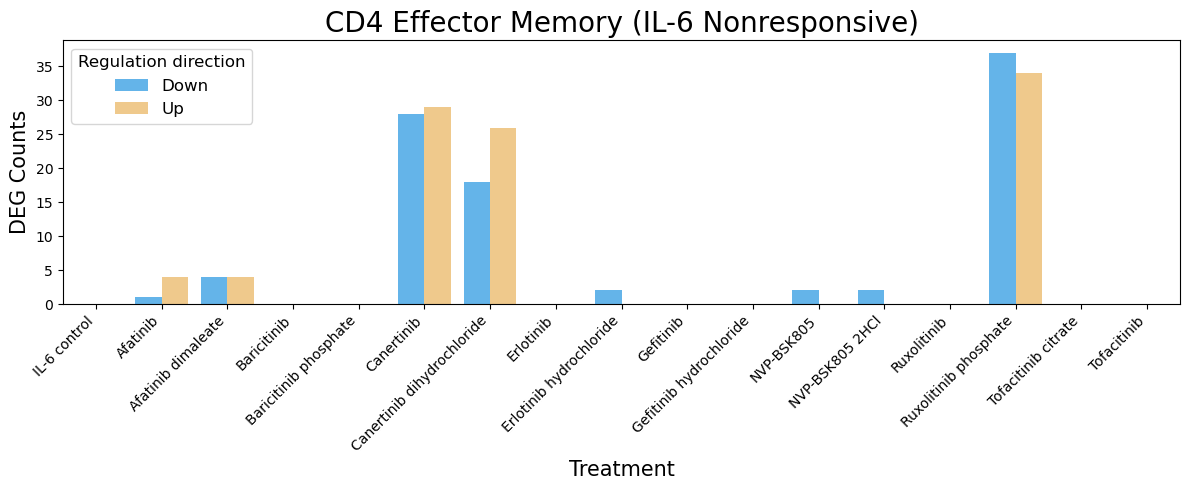

MAIT
              group   names    scores  logfoldchanges     pvals  pvals_adj  \
0      IL-6 control   SBNO2  2.669501        0.548107  0.007596   0.999799   
1      IL-6 control   NISCH  2.271718        0.721830  0.023104   0.999799   
2      IL-6 control    USP1  2.183334        0.447095  0.029011   0.999799   
3      IL-6 control     MAF  2.111663        0.440785  0.034715   0.999799   
4      IL-6 control   PRDM1  2.057409        0.421682  0.039647   0.999799   
...             ...     ...       ...             ...       ...        ...   
21466   Tofacitinib    CD37 -2.215544       -0.249159  0.026723   0.999910   
21467   Tofacitinib   STAT3 -2.345055       -0.322721  0.019024   0.999910   
21468   Tofacitinib   EOMES -2.397693       -0.448040  0.016499   0.999910   
21469   Tofacitinib   CYTH1 -2.567218       -0.239146  0.010252   0.999910   
21470   Tofacitinib  SQSTM1 -2.698645       -0.128130  0.006962   0.999910   

      cell_type  
0          MAIT  
1          MAIT  
2   

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


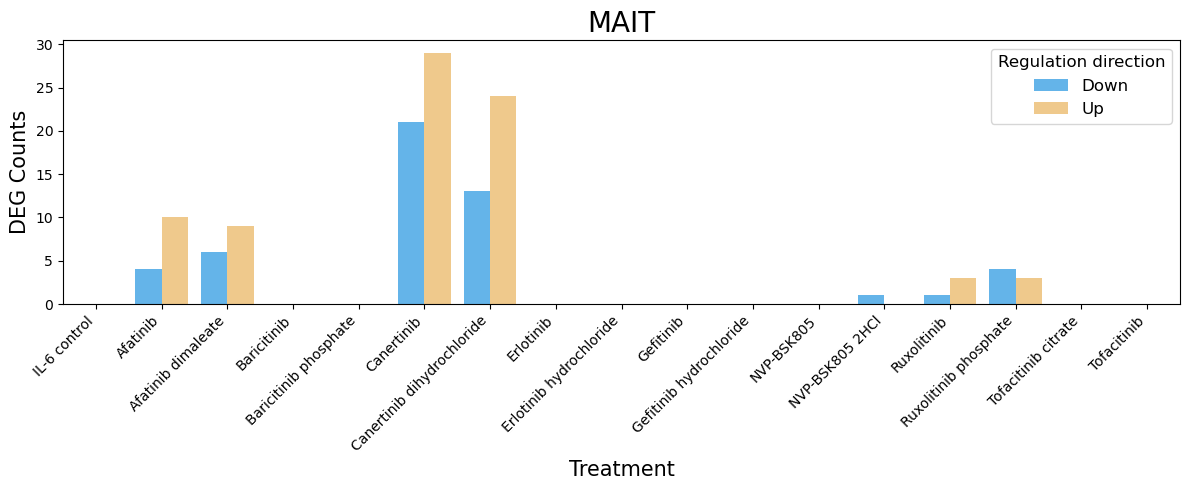

CD8 Effector Memory
              group   names    scores  logfoldchanges         pvals  \
0      IL-6 control   SBNO2  2.921534        0.344564  3.483128e-03   
1      IL-6 control    IRF4  2.806548        0.329614  5.007548e-03   
2      IL-6 control  LGALS8  2.415901        0.320705  1.569634e-02   
3      IL-6 control  TXNRD1  2.330785        0.281291  1.976472e-02   
4      IL-6 control    KTN1  2.297100        0.264253  2.161310e-02   
...             ...     ...       ...             ...           ...   
21092   Tofacitinib   PSMB9 -4.004116       -0.302400  6.224977e-05   
21093   Tofacitinib    CD52 -4.127452       -0.183443  3.668054e-05   
21094   Tofacitinib   TAPBP -4.517295       -0.058447  6.263446e-06   
21095   Tofacitinib   TXNIP -4.760663       -0.377442  1.929586e-06   
21096   Tofacitinib     B2M -5.372494       -0.030784  7.765502e-08   

       pvals_adj            cell_type  
0       0.270160  CD8 Effector Memory  
1       0.326991  CD8 Effector Memory  
2      

/tmp/ipykernel_760/1604745647.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/1604745647.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agreeing_counts_by_treatment = agreeing_df.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')


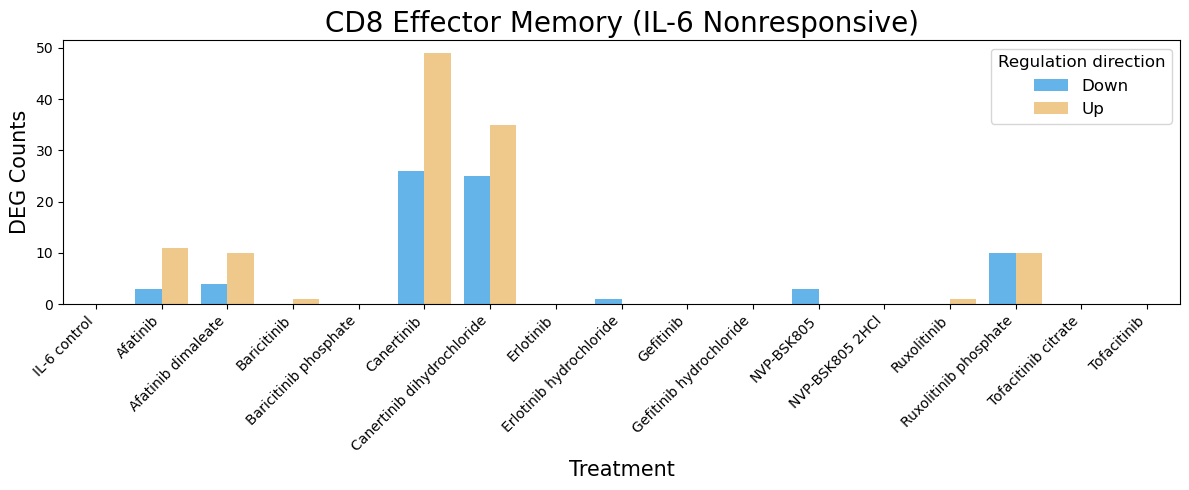

All cells
              cell_type regulation_dir  count
0    CD4 Central Memory           Down     34
1    CD4 Central Memory             Up     55
2   CD4 Effector Memory           Down     62
3   CD4 Effector Memory             Up     64
4             CD4 Naive           Down     85
5             CD4 Naive             Up    132
6    CD8 Central Memory           Down     34
7    CD8 Central Memory             Up     58
8   CD8 Effector Memory           Down     41
9   CD8 Effector Memory             Up     66
10            CD8 Naive           Down     63
11            CD8 Naive             Up    108
12                 MAIT           Down     30
13                 MAIT             Up     37
14                 Treg           Down     43
15                 Treg             Up     79
                names
regulation_dir       
Down              156
Up                242


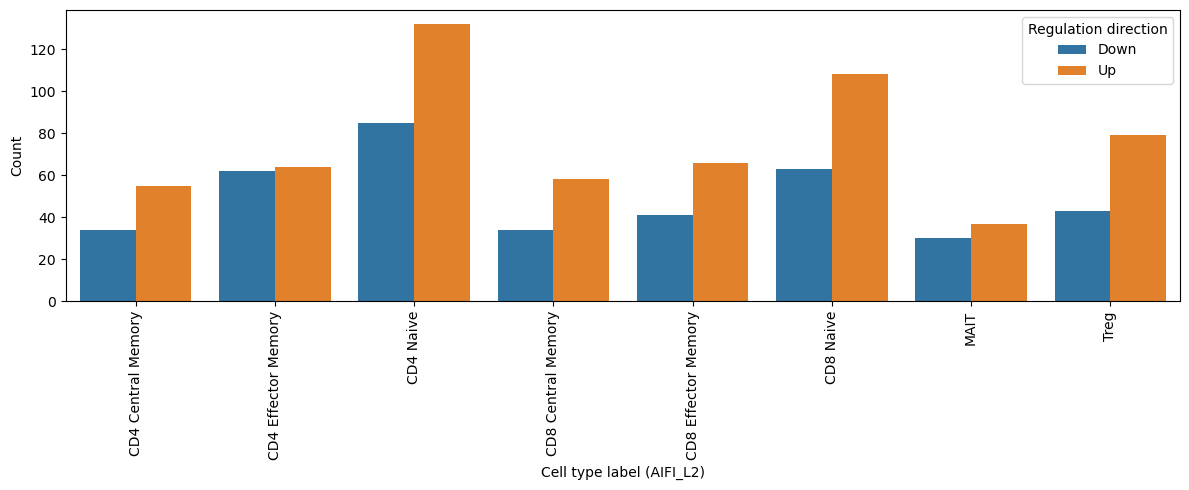

              group  names     scores  logfoldchanges          pvals  \
0      IL-6 control  SBNO2  60.260761        2.309811   0.000000e+00   
1      IL-6 control  IKZF1  39.254021        0.647633   0.000000e+00   
2      IL-6 control  IL2RB  38.148853        1.983307   0.000000e+00   
3      IL-6 control  IFI16  36.474274        0.743574  2.837282e-291   
4      IL-6 control  STAT3  36.020184        1.292323  4.041929e-284   
...             ...    ...        ...             ...            ...   
21092   Tofacitinib  PSMB9  -4.004116       -0.302400   6.224977e-05   
21093   Tofacitinib   CD52  -4.127452       -0.183443   3.668054e-05   
21094   Tofacitinib  TAPBP  -4.517295       -0.058447   6.263446e-06   
21095   Tofacitinib  TXNIP  -4.760663       -0.377442   1.929586e-06   
21096   Tofacitinib    B2M  -5.372494       -0.030784   7.765502e-08   

           pvals_adj            cell_type  abs_logfoldchanges  
0       0.000000e+00   CD4 Central Memory            2.309811  
1      

In [9]:
graph_diff_gene_counts_with_agreement(lfc_threshold = 1)

And now uploading these dataframes to HISE as CSVs:

In [10]:
# starting off with a function to make unique destination strings with periodic table elements
def element_id(n = 3):
    import periodictable
    from random import randrange
    rand_el = []
    
    for i in range(n):
        el = randrange(0,118)
        rand_el.append(periodictable.elements[el].name)
        
    rand_str = '-'.join(rand_el)
    return rand_str

In [11]:
help(hisepy.upload_files)

Help on function upload_files in module hisepy.upload:

upload_files(
    files: list,
    study_space_id: str = None,
    project: str = None,
    title: str = None,
    input_file_ids: list = [],
    input_sample_ids: list = [],
    file_types: list = [],
    store: str = None,
    destination: str = '',
    do_prompt: bool = True,
    do_conda_build_check=True
)
    Uploads files to a store and records their provenance in HISE, but V3

    Parameters:
        files (list): absolute filepath of file to be uploaded
        study_space_id (str): ID that pertains to a study in the collaboration space (optional)
        project (str): project short name (required if study space is not specified, defaults to the ide's default setting
        title (str): 10+ character title for upload result
        input_file_ids (list): fileIds from HISE that were utilized to generate a user's result
        input_sample_ids (list): sampleIds from HISE that were utilized to generate a user's result
    

In [12]:
# need unique title for upload, using UTC time
from datetime import datetime, timezone

utc_current = datetime.now(timezone.utc)
print(utc_current)

# todo: should probably clean up the names here of these csvs... just replace "." with "_" in the threshold?
files_to_upload = [
    "wilcoxon_deg_counts_logfc_0.1.csv",
    "wilcoxon_deg_counts_logfc_1.csv",
    "wilcoxon_deg_results.csv"
]

hisepy.upload_files(
    files = files_to_upload,
    study_space_id = "c8a94b84-b0b7-40a9-980b-81a63ad6e115",
    title = f"cell_treatment_deg_{utc_current}",
    input_file_ids = uuid_list,
    destination = element_id()
)

2026-02-17 20:06:55.112036+00:00
checking if conda environment can compile...
creating temp conda environment...
temp conda environment created successfully, now packing...


{'Message': 'General Okay-ness',
 'VisualizationId': '00000000-0000-0000-0000-000000000000',
 'AbstractionId': '00000000-0000-0000-0000-000000000000',
 'TraceId': 'e6c68bf1-3dbc-49d1-8538-32c781765de1',
 'ProcessId': '3e756656-c0d6-42c2-94d1-6b0ded916b47',
 'WorkflowId': '447033e2-57a6-4c60-9357-faac708f564a',
 'FileIds': ['33fde485-1304-448f-a21c-cfd5e6beebb7',
  '64f20141-07cd-4435-bda8-3c20f3c05848',
  '7be501b7-5f99-4728-b4e8-1563799cac6f']}

### Comparing against IL-6 control significant genes

In [13]:
# todo: add distinction for gene regulation in common with IL6
# todo: adjust the threshold to 0.1 as well

# tracking all gene names that are up/down regulated in any cell
up_across_cells = set()
down_across_cells = set()

# add in grouping by drug
# plot as bar plot or heat map


def graph_diff_gene_counts(lfc_threshold):
    # initialize the dataframe
    all_cells_sig_genes = pd.DataFrame({'cell_type':[], 'names': [], 'regulation_dir': []})
    
    for cell_type, subset_cell in subsets_cells.items():

        cell_df = sc.get.rank_genes_groups_df(subset_cell, group=None)
    
        # make a column that is absolute value of logfold change
        cell_df['abs_logfoldchanges'] = cell_df['logfoldchanges'].abs()
    
        # filter for absolute value of log fold change > 1 and adjusted p values less than 0.05
        sig_diff = cell_df[(cell_df['pvals_adj'] < 0.05) & (cell_df['abs_logfoldchanges'] > lfc_threshold)].sort_values(by = 'abs_logfoldchanges', ascending = False)
        
        # add a categorical variable showing up or down regulation
        sig_diff['regulation_dir'] = np.where(sig_diff['logfoldchanges'] > 0, 'Up', 'Down')
        sig_diff['cell_type'] = cell_type
        # print(sig_diff.head())
    
        
        counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
    
        # print(sig_diff.groupby('regulation')['regulation'].count())
        # concatenating these to our data frame across all cell types with a label for what the cell type is
        # also making it unique so we don't have duplicate counts across different treatment types
        all_cells_sig_genes = pd.concat([all_cells_sig_genes, sig_diff[['cell_type', 'names', 'regulation_dir']]]).drop_duplicates()
    all_cells_sig_genes.to_csv("all_cells_sig_genes.csv")
    


In [14]:
graph_diff_gene_counts(0.1)

/tmp/ipykernel_760/483244995.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/483244995.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_by_treatment = sig_diff.groupby(['group', 'regulation_dir'])['regulation_dir'].count().reset_index(name='count')
/tmp/ipykernel_760/483244995.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed

## Old heatmaps/dotplots
Let's start with the top 500 differentially expressed genes

CD4 Central Memory
Only selecting for top 500 log fold change
                            group   names     scores  logfoldchanges  \
6300                   Canertinib   HMGB2  55.764740        2.965033   
7560   Canertinib dihydrochloride   HMGB2  55.677532        2.919789   
6304                   Canertinib    BATF  32.710278        2.355659   
1265                     Afatinib    BATF  33.126328        2.346632   
7533                   Canertinib   SMAD7 -17.584675       -2.343118   
...                           ...     ...        ...             ...   
76                   IL-6 control   IFI35   6.418116        0.842732   
7588   Canertinib dihydrochloride  STAT5A  14.925355        0.842079   
2545           Afatinib dimaleate   CCND2  16.780336        0.841803   
12587                   Gefitinib   TXNIP -20.648844       -0.841526   
7831   Canertinib dihydrochloride   ABCB6   2.371076        0.840145   

               pvals      pvals_adj  abs_logfoldchanges  
6300    0.00000

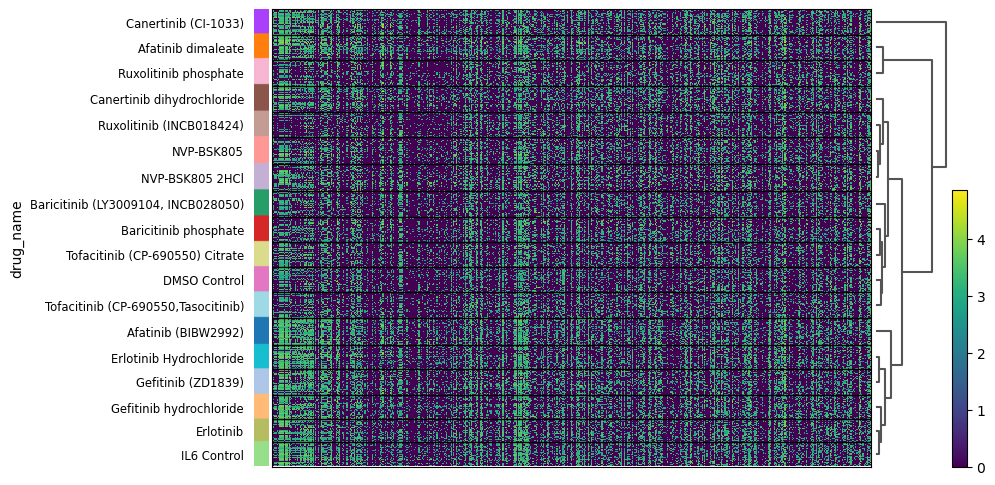

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: IL-6 control, Afatinib, Afatinib dimaleate, etc.


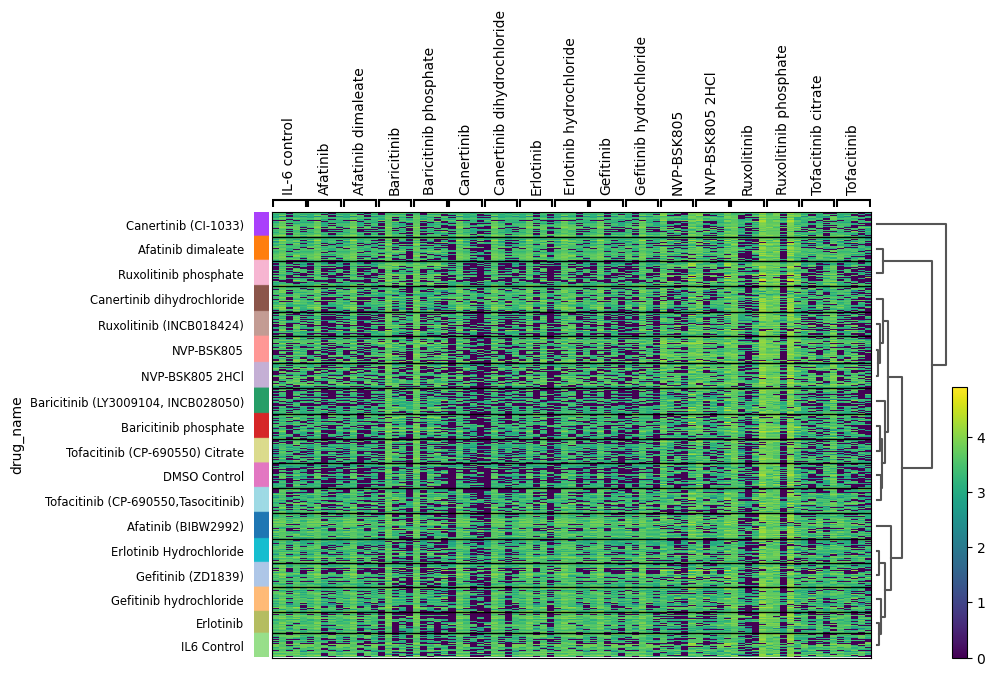

CD8 Naive
Only selecting for top 500 log fold change
                            group  names     scores  logfoldchanges  \
2373           Afatinib dimaleate   BATF  42.452785        4.830195   
1186                     Afatinib   BATF  42.078945        4.809808   
5925                   Canertinib  HMGB2  60.987823        4.656802   
7116   Canertinib dihydrochloride   BATF  39.566795        4.596536   
10670                   Gefitinib   BATF  38.806232        4.562941   
...                           ...    ...        ...             ...   
8320                    Erlotinib  HIF1A  16.166233        1.251970   
1287                     Afatinib   DPP4   6.416355        1.251775   
153                  IL-6 control   LY96   4.839973        1.250281   
8435                    Erlotinib   MUC1   4.592098        1.249510   
9493      Erlotinib hydrochloride   TWF2  24.894566        1.249283   

               pvals      pvals_adj  abs_logfoldchanges  
2373    0.000000e+00   0.000000e+00 

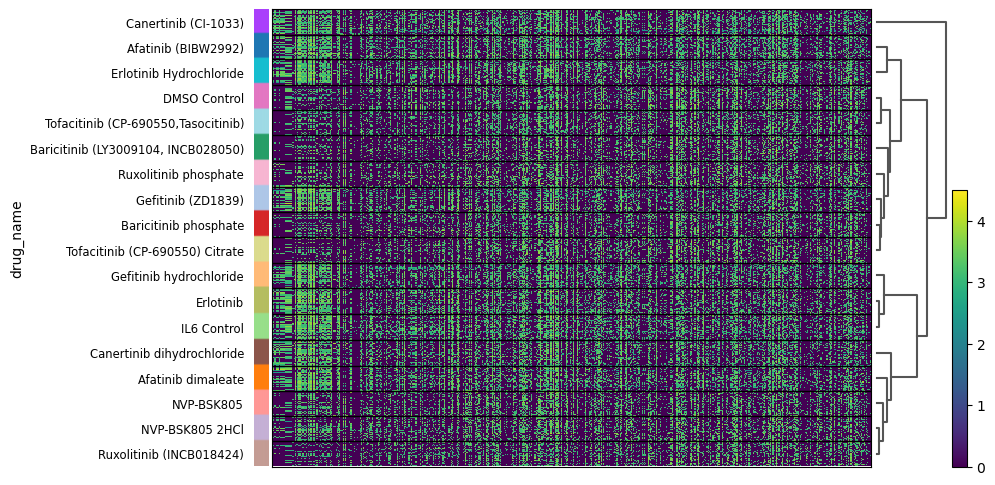

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: IL-6 control, Afatinib, Afatinib dimaleate, etc.


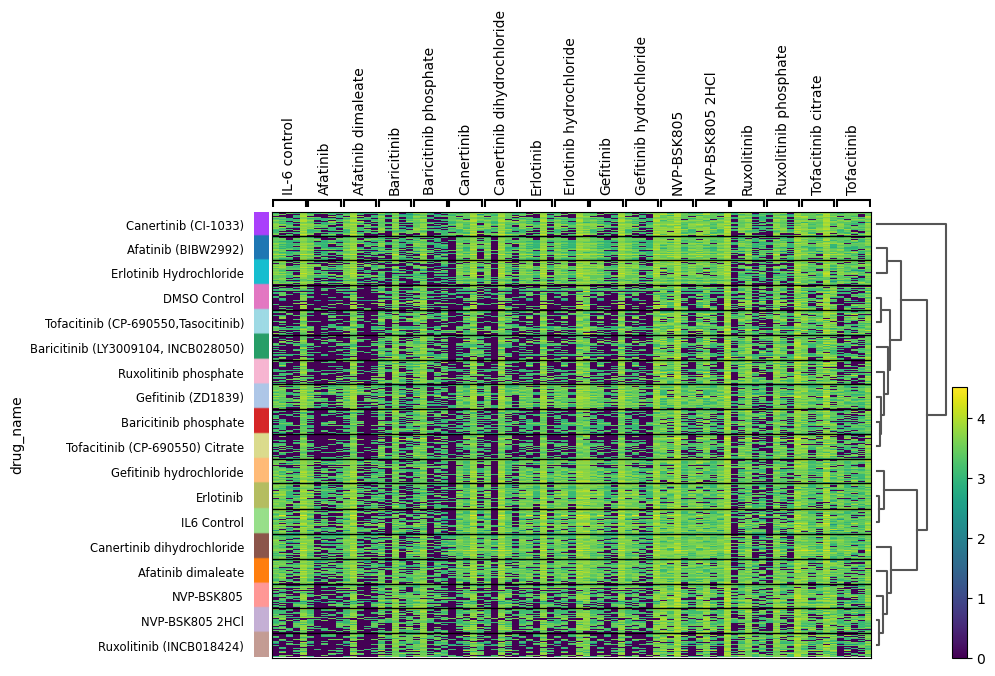

CD4 Naive
Only selecting for top 500 log fold change
                            group  names     scores  logfoldchanges  \
1173                     Afatinib   BATF  61.560120        4.998376   
2346           Afatinib dimaleate   BATF  60.699821        4.891921   
5                    IL-6 control   BATF  56.930550        4.704328   
10550                   Gefitinib   BATF  56.004692        4.688774   
11725     Gefitinib hydrochloride   BATF  56.490063        4.681890   
...                           ...    ...        ...             ...   
6082                   Canertinib   JPT1   3.190105        1.524120   
7138   Canertinib dihydrochloride  FKBP4   8.885480        1.521944   
12891     Gefitinib hydrochloride    CD5 -60.891006       -1.520784   
96                   IL-6 control  SOCS2   9.676761        1.520554   
8163   Canertinib dihydrochloride    JUN -25.420883       -1.519128   

               pvals      pvals_adj  abs_logfoldchanges  
1173    0.000000e+00   0.000000e+00 

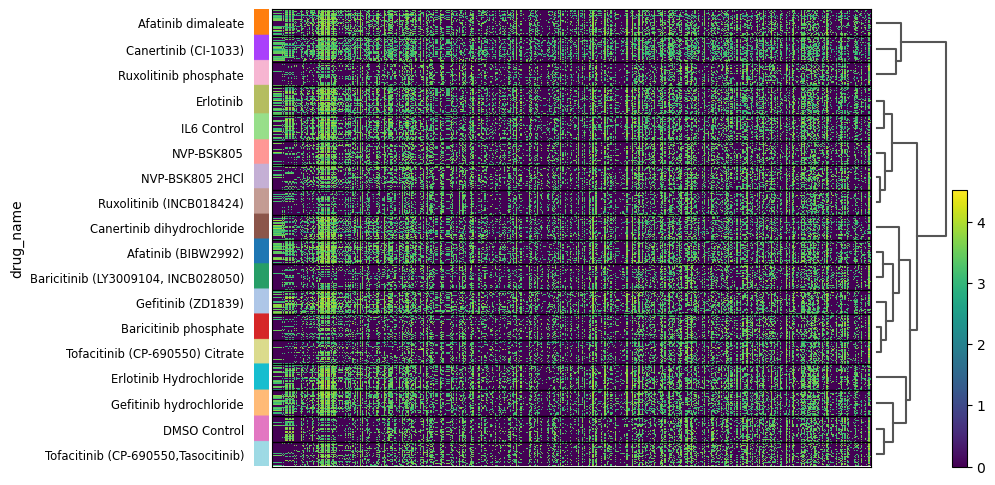

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: IL-6 control, Afatinib, Afatinib dimaleate, etc.


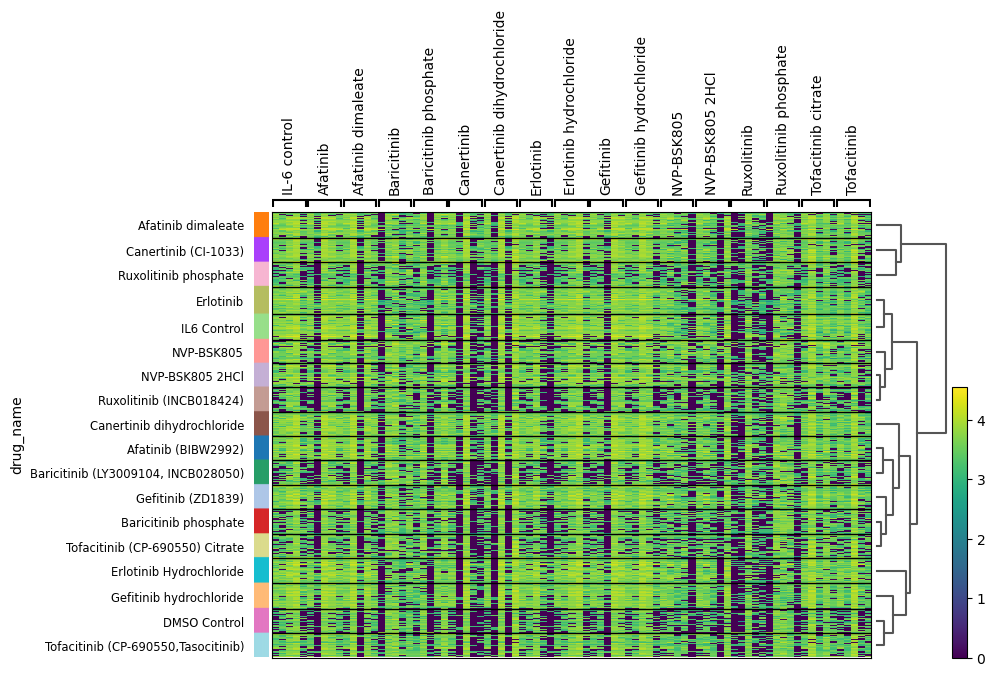

Treg
Only selecting for top 500 log fold change
                            group   names     scores  logfoldchanges  \
8251   Canertinib dihydrochloride   SMAD7  -6.775254       -3.518933   
7071                   Canertinib   SMAD7  -6.729897       -3.515301   
5925                   Canertinib   HMGB2  26.781143        3.280865   
5924        Baricitinib phosphate   STAT1 -18.984890       -3.197313   
7110   Canertinib dihydrochloride   HMGB2  25.815134        3.182686   
...                           ...     ...        ...             ...   
9523      Erlotinib hydrochloride   HIF1A   5.337300        1.045513   
10696                   Gefitinib  STAT5A   7.521023        1.043409   
5955                   Canertinib  STAT5A   7.600379        1.043302   
7152   Canertinib dihydrochloride      F5   6.346048        1.042831   
7121   Canertinib dihydrochloride    IL32  12.318175        1.041982   

               pvals      pvals_adj  abs_logfoldchanges  
8251    1.241880e-11   1.8628

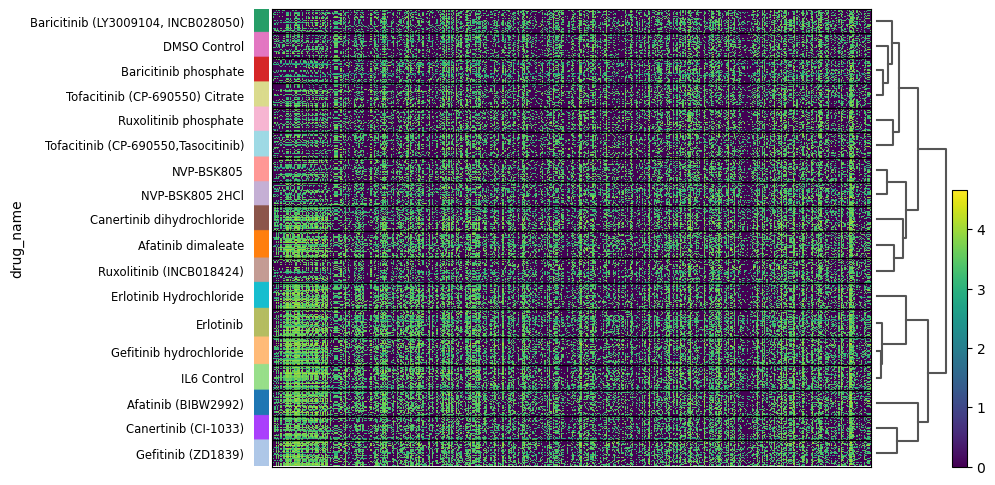

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: IL-6 control, Afatinib, Afatinib dimaleate, etc.


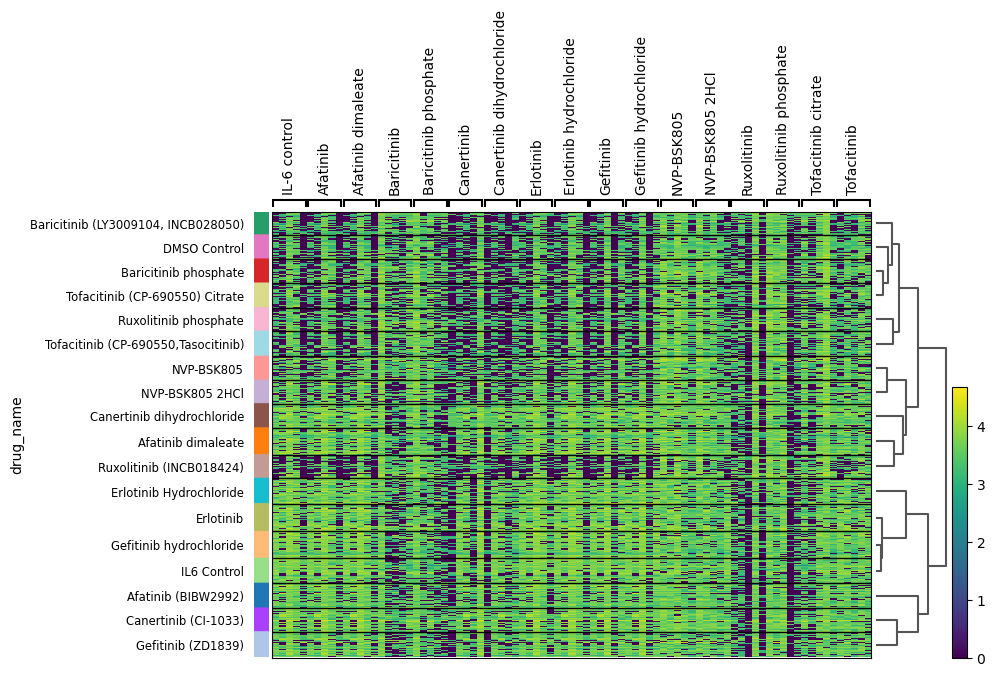

CD8 Central Memory
Only selecting for top 500 log fold change
                            group     names     scores  logfoldchanges  \
6240                   Canertinib     HMGB2  29.410284        3.601888   
7488   Canertinib dihydrochloride     HMGB2  27.794371        3.520540   
7482                   Canertinib    SEMA7A -16.360149       -3.496383   
8731   Canertinib dihydrochloride    SEMA7A -15.151285       -3.170068   
1249                     Afatinib       FOS  18.983759        2.992201   
...                           ...       ...        ...             ...   
8721   Canertinib dihydrochloride  APOBEC3G -11.181317       -0.731431   
2588           Afatinib dimaleate      POLB   3.087282        0.731164   
16233                 Ruxolitinib    SIGIRR   6.950463        0.729290   
1254                     Afatinib      JUNB  11.123879        0.729142   
4995        Baricitinib phosphate     DUSP1   6.520628        0.729049   

               pvals      pvals_adj  abs_logfoldc

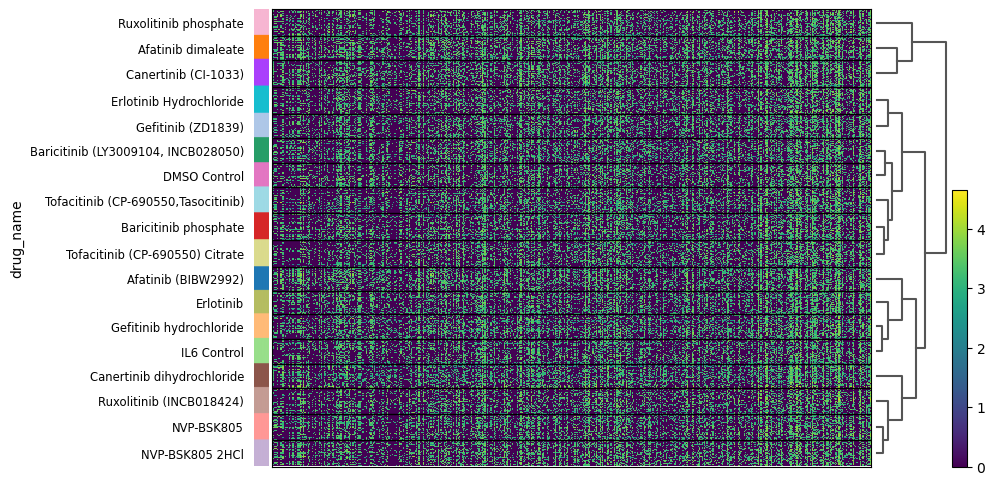

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: IL-6 control, Afatinib, Afatinib dimaleate, etc.


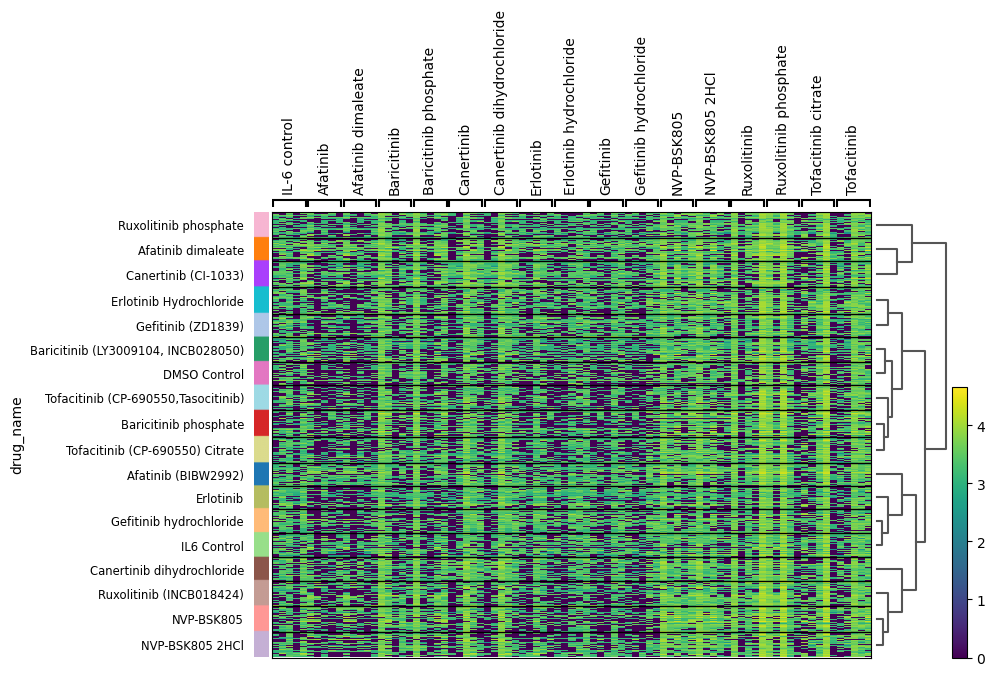

CD4 Effector Memory
Only selecting for top 500 log fold change
                            group     names     scores  logfoldchanges  \
18059       Ruxolitinib phosphate     TXNIP -35.431580       -2.895997   
6020                   Canertinib     HMGB2  39.195019        2.880967   
7224   Canertinib dihydrochloride     HMGB2  37.178181        2.774132   
6075                   Canertinib    HSPA1A   6.832606        2.310551   
6033                   Canertinib      DDB2  14.163255        2.183915   
...                           ...       ...        ...             ...   
15655                 Ruxolitinib    SIGIRR  10.834989        0.688738   
3600           Afatinib dimaleate       LAT  -7.295962       -0.688489   
13354                  NVP-BSK805     RRP12   4.756881        0.687701   
18015       Ruxolitinib phosphate  TNFRSF25  -7.820444       -0.687602   
17827       Ruxolitinib phosphate      PIN1  -2.378553       -0.687583   

               pvals      pvals_adj  abs_logfold

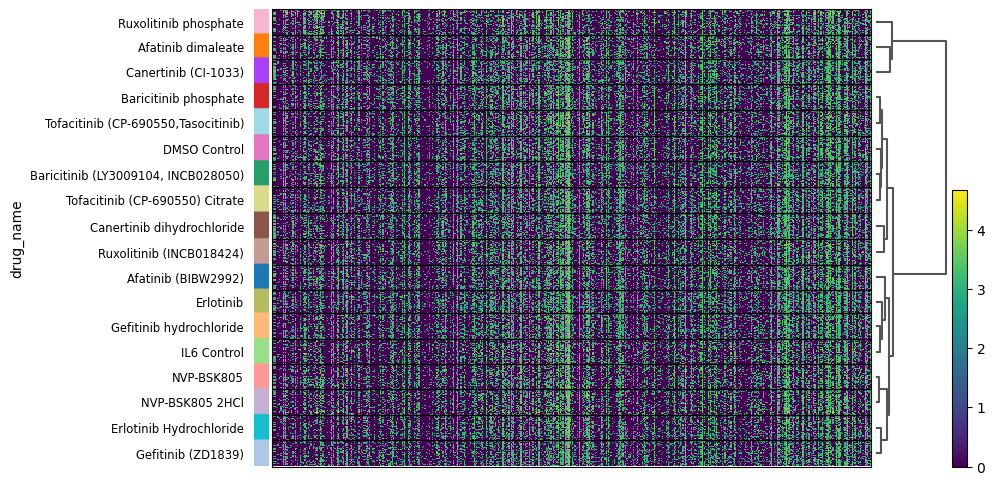

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: IL-6 control, Afatinib, Afatinib dimaleate, etc.


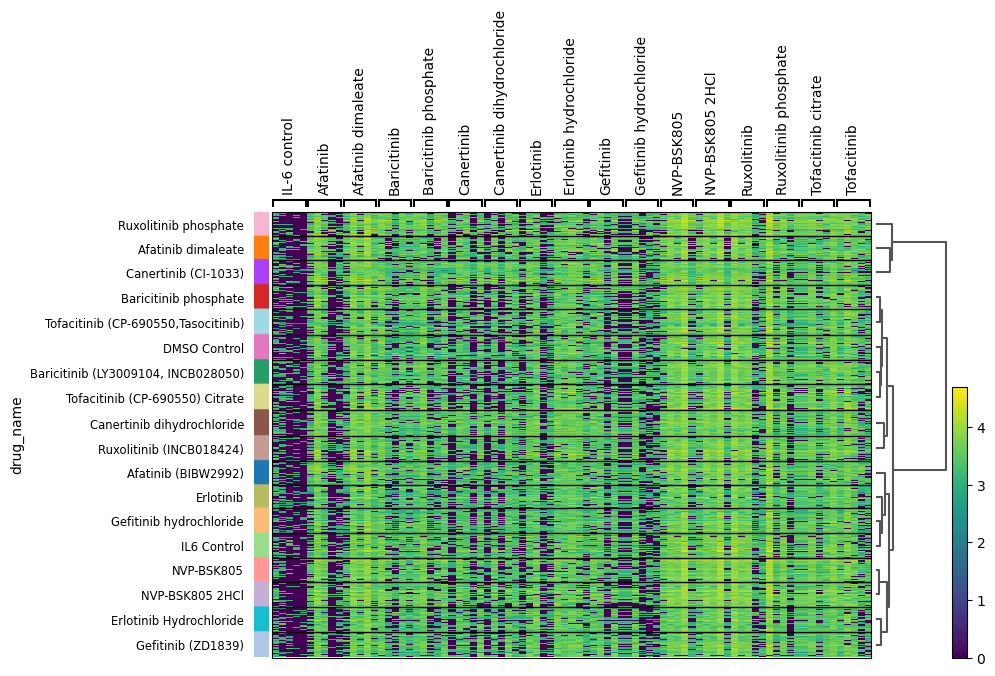

MAIT
Only selecting for top 500 log fold change
                            group   names     scores  logfoldchanges  \
8782   Canertinib dihydrochloride   LAMA3  -3.572174       -2.807184   
6316                   Canertinib   HMGB2  11.475610        2.735796   
7580   Canertinib dihydrochloride   HMGB2  10.837173        2.606860   
8833   Canertinib dihydrochloride  SEMA7A  -7.962275       -2.600801   
7564                   Canertinib  SEMA7A  -7.856130       -2.553416   
...                           ...     ...        ...             ...   
15159             NVP-BSK805 2HCl  STAT5B   5.189760        0.352671   
12615                   Gefitinib    RGS2  -3.662142       -0.347891   
2521                     Afatinib    CD96  -5.988506       -0.347151   
17719       Ruxolitinib phosphate  STAT5A   3.567110        0.346377   
6317                   Canertinib  SQSTM1  10.122724        0.346310   

              pvals     pvals_adj  abs_logfoldchanges  
8782   3.540306e-04  4.178884e-

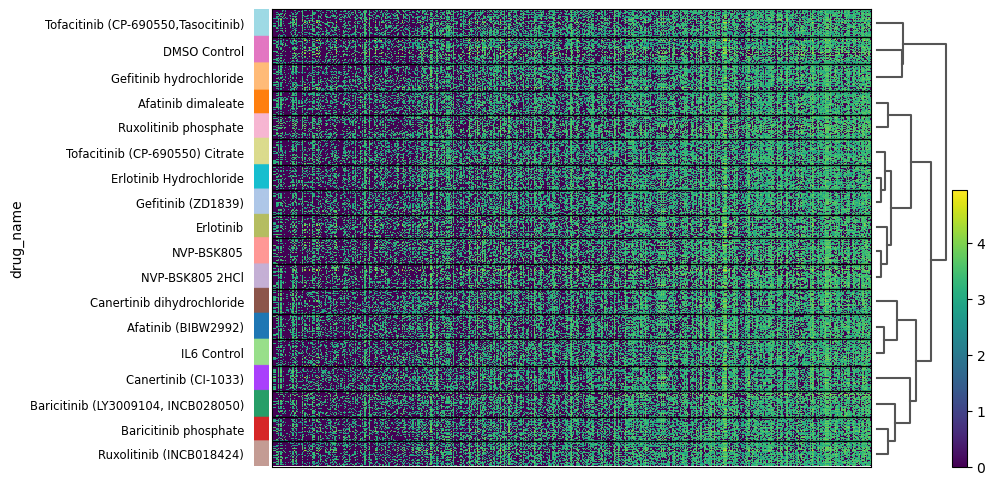

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: IL-6 control, Afatinib, Afatinib dimaleate, etc.


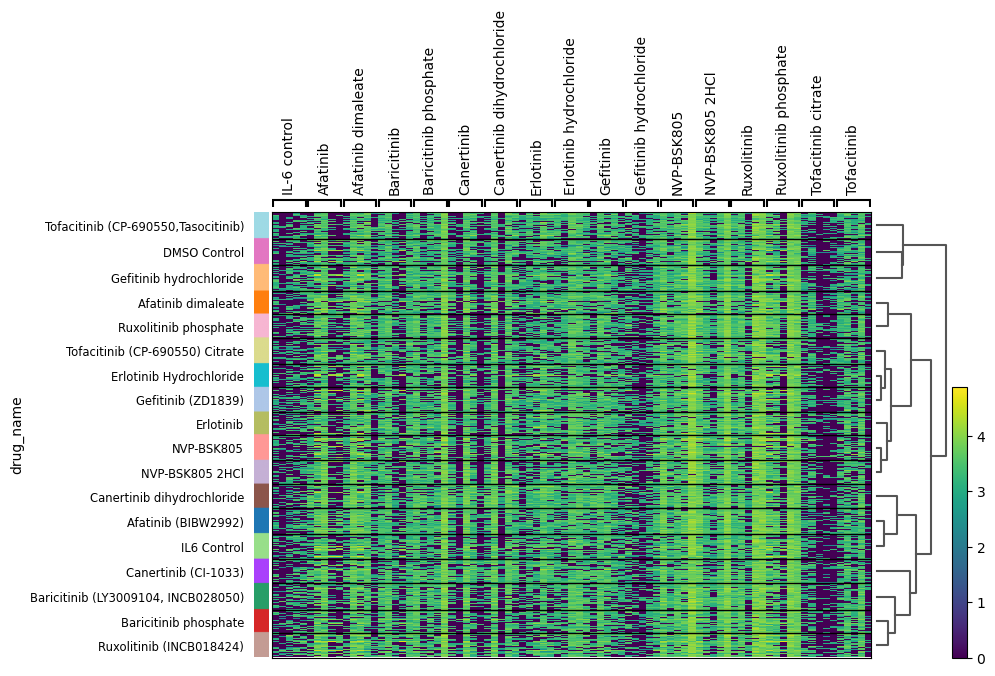

CD8 Effector Memory
Only selecting for top 500 log fold change
                            group    names     scores  logfoldchanges  \
6205                   Canertinib    HMGB2  33.895832        2.888356   
7446   Canertinib dihydrochloride    HMGB2  32.443760        2.827512   
6233                   Canertinib  ADORA2A   9.880302        2.704105   
6206                   Canertinib   TXNRD1  31.263695        2.505210   
7481   Canertinib dihydrochloride  ADORA2A   8.070732        2.409409   
...                           ...      ...        ...             ...   
7584   Canertinib dihydrochloride     IL4R   3.510192        0.668939   
8609   Canertinib dihydrochloride     RPA1  -6.305546       -0.668706   
16082             NVP-BSK805 2HCl    ICAM2  -2.730161       -0.668325   
6385                   Canertinib      GRN   2.673435        0.668068   
7556   Canertinib dihydrochloride    ACAA1   4.102512        0.667432   

               pvals      pvals_adj  abs_logfoldchanges  
62

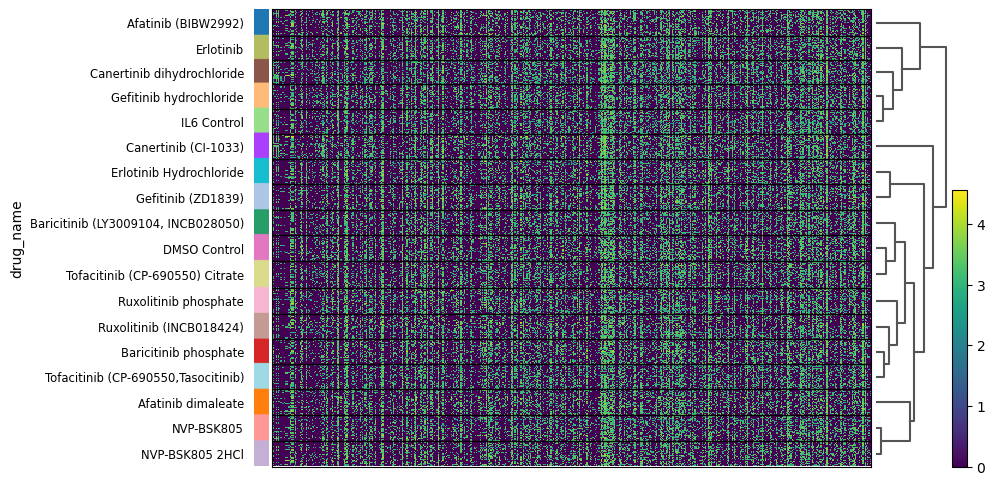

categories: Afatinib (BIBW2992), Afatinib dimaleate, Baricitinib (LY3009104, INCB028050), etc.
var_group_labels: IL-6 control, Afatinib, Afatinib dimaleate, etc.


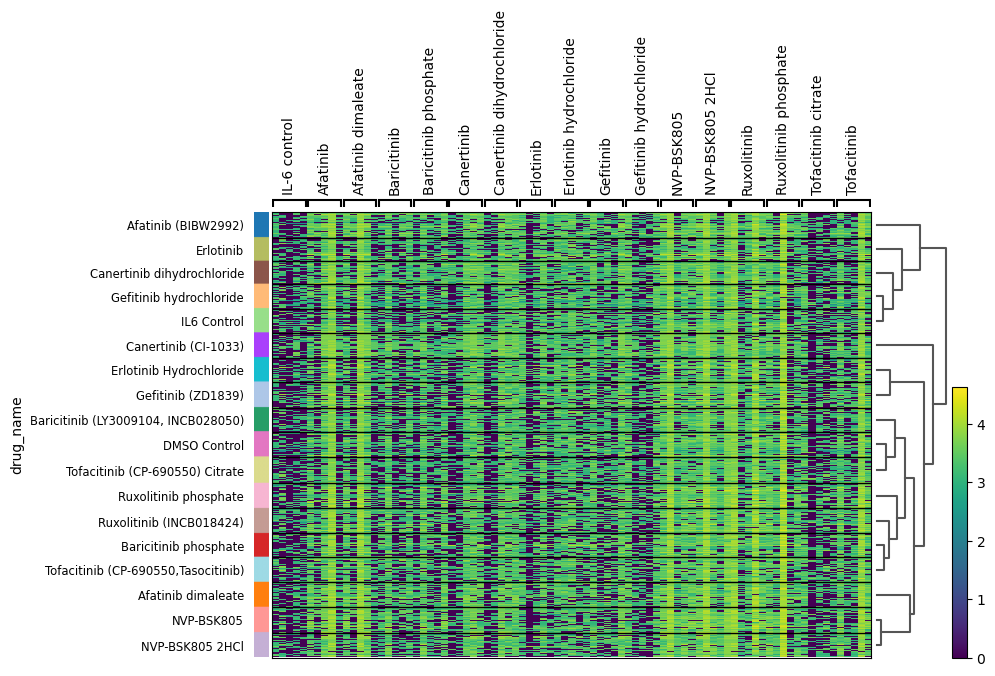

557


In [15]:
# filtering for p values less than 0.05 then sorting by log fold change

# adding this in to do a comprehensive heatmap across cell types
top_across_cells = set()

for cell_type, subset_cell in subsets_cells.items():
    print("================================")
    print(cell_type)
    print("Only selecting for top 500 log fold change")
    print("================================")
    # print(subset_cell.uns['rank_genes_groups'].keys())
    # subset_cell.uns['rank_genes_groups']
    # sc.pl.heatmap(subset_cell)
    cell_df = sc.get.rank_genes_groups_df(subset_cell, group=None)
    cell_df['abs_logfoldchanges'] = cell_df['logfoldchanges'].abs()
    # print(cell_df.head())
    # 0.05 should be good enough for an *adjusted* p value
    top_500_df = cell_df[cell_df['pvals_adj'] < 0.05].sort_values(by = "abs_logfoldchanges", ascending = False).head(500)
    print(top_500_df)


    top_500_genes = list(top_500_df["names"])
    for gene_name in top_500_genes:
        top_across_cells.add(gene_name)
    # print(top_500_genes)

    sc.pl.heatmap(subset_cell, top_500_genes, groupby = "drug_name", layer = "log_transformed", dendrogram=True)
    sc.pl.rank_genes_groups_heatmap(subset_cell, groupby="drug_name", n_genes=5)

print(len(top_across_cells))

# sc.pl.rank_genes_groups_heatmap(adata, layer = "")

It looks like, by selecting the top up/down regulated 500 significant DEGs for each cell type we wind up with 558 genes across all cell types. Let's look at these in a heatmap across all the cell types.

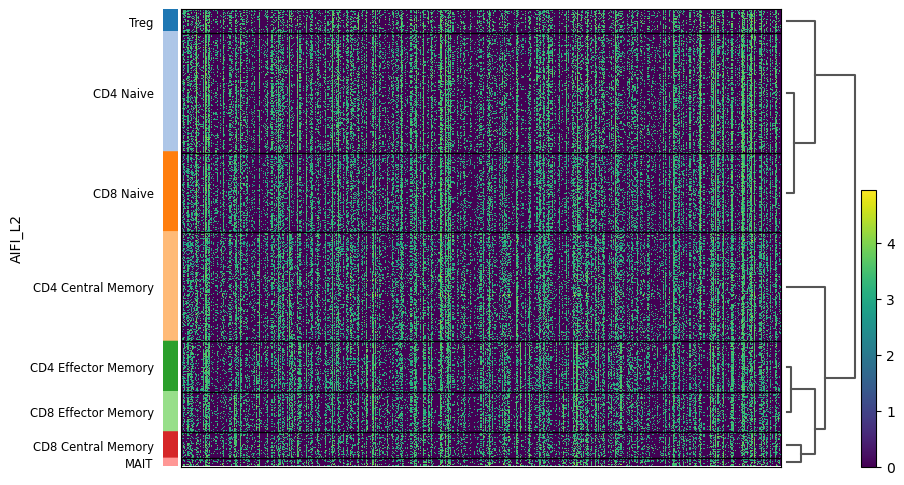

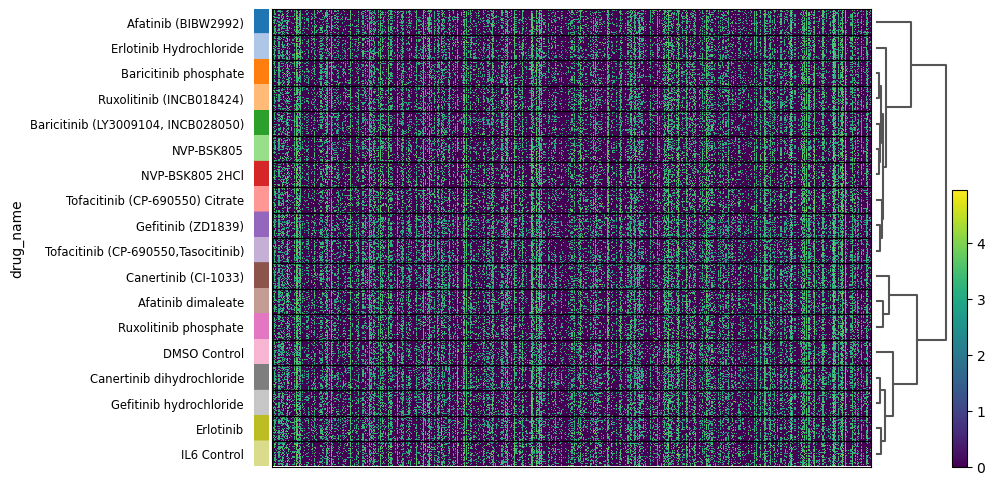

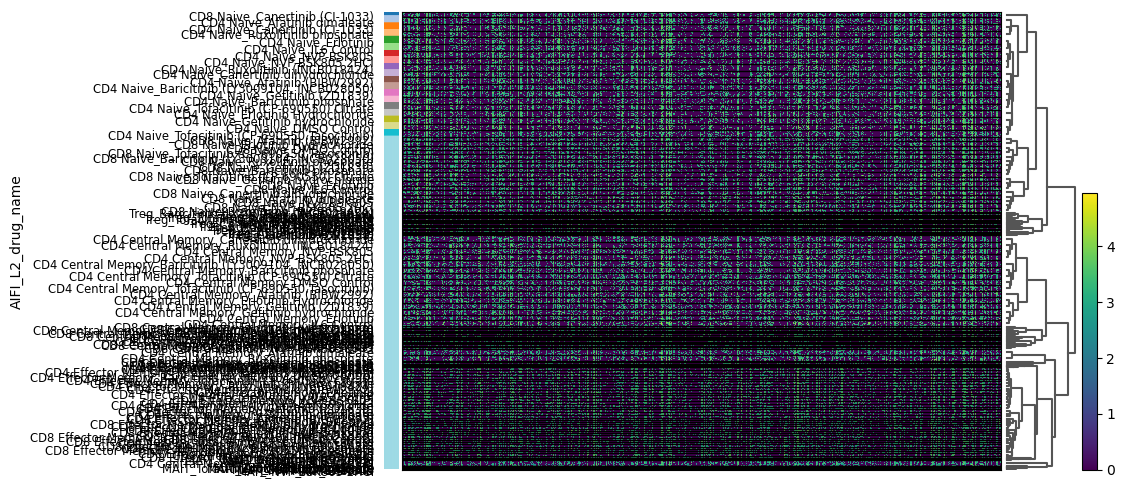

In [16]:
top_across_cells = list(top_across_cells)

sc.pl.heatmap(adata, top_across_cells, groupby = ["AIFI_L2"],  layer = "log_transformed", dendrogram=True)

sc.pl.heatmap(adata, top_across_cells, groupby = ["drug_name"],  layer = "log_transformed", dendrogram=True)

# trying to figure out 
sc.pl.heatmap(adata, top_across_cells, groupby = ["AIFI_L2", "drug_name"],  layer = "log_transformed", dendrogram=True)

In [17]:
# trying this again but also filtering for absolute value of log fold change values greater than 1 as well
# adding this in to do a comprehensive heatmap across cell types

#todo: 

top_across_cells = set()

top_n = 20
for cell_type, subset_cell in subsets_cells.items():
    print("================================")
    print(cell_type)
    print("Filtering for log fold change > 1 and then for top 500")
    print("================================")
    # print(subset_cell.uns['rank_genes_groups'].keys())
    # subset_cell.uns['rank_genes_groups']
    # sc.pl.heatmap(subset_cell)
    cell_df = sc.get.rank_genes_groups_df(subset_cell, group=None)
    cell_df['abs_logfoldchanges'] = cell_df['logfoldchanges'].abs()

    # print(cell_df)
    # print(cell_df.head())
    # 0.05 should be good enough for an *adjusted* p value
    # can leave logfold change filter to 1 for just top results
    top_genes_df = cell_df[(cell_df['pvals_adj'] < 0.05) & (cell_df['abs_logfoldchanges'] > .1) & (cell_df["group"] == "IL-6 Control")]
    top_genes_df = top_genes_df.sort_values(by = "abs_logfoldchanges", ascending = False)
    print(top_genes_df)
    
    top_genes = top_genes_df['names'].unique()[:top_n]
    print(top_genes)


    for gene_name in top_genes:
        top_across_cells.add(gene_name)
    # print(top_500_genes)

    # including this if statement because some cell types don't have any significantly up/down regulated genes for IL6
    if top_genes.size > 0:
        file_name = f'figures/dot_plot_{cell_type}_top_{top_n}.svg'.replace(' ', '_')
        # help(ax)

        sc.pl.dotplot(subset_cell, top_genes, groupby = "clean_drug_name", layer = "log_transformed", dendrogram=True, 
          save=f'{cell_type}_top_{top_n}.svg'.replace(' ', '_'))


        # # attempting to rotate the gene names 45 degrees -- not working because it is reframing the figure and cutting things off:
        
        # dp = sc.pl.dotplot(subset_cell, top_genes, groupby = "clean_drug_name", layer = "log_transformed", dendrogram=True, return_fig=True)
        
        # # get matplotlib axes from the figure object
        # axes_dict = dp.get_axes()
        # # print(axes_dict)

        # # assign the axes we care about
        # ax = axes_dict['mainplot_ax']

        # # change the properties of that axis
        # ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

        # # help(ax.set_xticklabels)
        # # ax.tick_params(rotation = 45, ha = 'right')
        # plt.savefig(file_name)
        # plt.show()
    
    else:
        print("No significant top genes found.")
    # sc.pl.rank_genes_groups_heatmap(subset_cell, groupby="drug_name", n_genes=5)

# print(len(top_across_cells))

# sc.pl.rank_genes_groups_heatmap(adata, layer = "")

CD4 Central Memory
Filtering for log fold change > 1 and then for top 500
Empty DataFrame
Columns: [group, names, scores, logfoldchanges, pvals, pvals_adj, abs_logfoldchanges]
Index: []
[]
No significant top genes found.
CD8 Naive
Filtering for log fold change > 1 and then for top 500
Empty DataFrame
Columns: [group, names, scores, logfoldchanges, pvals, pvals_adj, abs_logfoldchanges]
Index: []
[]
No significant top genes found.
CD4 Naive
Filtering for log fold change > 1 and then for top 500
Empty DataFrame
Columns: [group, names, scores, logfoldchanges, pvals, pvals_adj, abs_logfoldchanges]
Index: []
[]
No significant top genes found.
Treg
Filtering for log fold change > 1 and then for top 500
Empty DataFrame
Columns: [group, names, scores, logfoldchanges, pvals, pvals_adj, abs_logfoldchanges]
Index: []
[]
No significant top genes found.
CD8 Central Memory
Filtering for log fold change > 1 and then for top 500
Empty DataFrame
Columns: [group, names, scores, logfoldchanges, pvals, pva

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/scanpy/plotting/_anndata.py:1328: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = heatmap_ax.imshow(obs_tidy.values, aspect="auto", norm=norm, **kwds)
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/scanpy/plotting/_anndata.py:1331: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  heatmap_ax.set_xlim(-0.5, obs_tidy.shape[1] - 0.5)


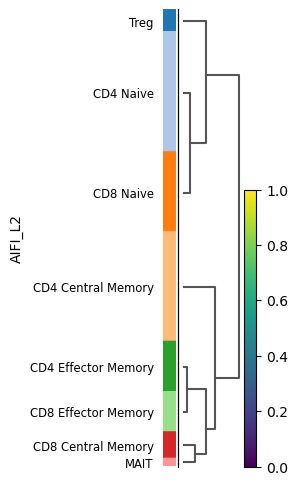

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/scanpy/plotting/_anndata.py:1328: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = heatmap_ax.imshow(obs_tidy.values, aspect="auto", norm=norm, **kwds)
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/scanpy/plotting/_anndata.py:1331: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  heatmap_ax.set_xlim(-0.5, obs_tidy.shape[1] - 0.5)


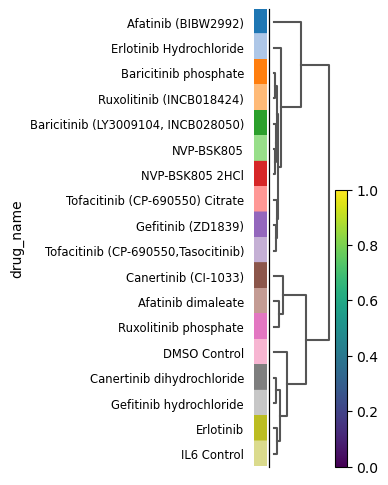

/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/scanpy/plotting/_anndata.py:1328: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = heatmap_ax.imshow(obs_tidy.values, aspect="auto", norm=norm, **kwds)
/home/workspace/environment/pythonscrna12/lib/python3.13/site-packages/scanpy/plotting/_anndata.py:1331: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  heatmap_ax.set_xlim(-0.5, obs_tidy.shape[1] - 0.5)


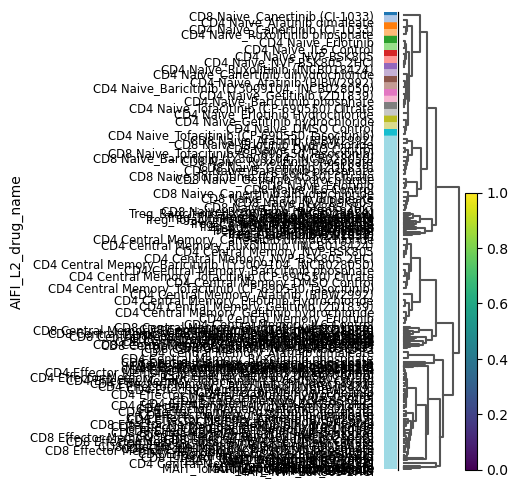

In [18]:
top_across_cells = list(top_across_cells)

sc.pl.heatmap(adata, top_across_cells, groupby = ["AIFI_L2"],  layer = "log_transformed", dendrogram=True)

sc.pl.heatmap(adata, top_across_cells, groupby = ["drug_name"],  layer = "log_transformed", dendrogram=True)


plt.rcParams['figure.figsize'] = (10, 15)
# trying to figure out 
sc.pl.heatmap(adata, top_across_cells, groupby = ["AIFI_L2", "drug_name"], layer = "log_transformed", dendrogram=True)

In [19]:
help(sc.pl.violin)

Help on function violin in module scanpy.plotting._anndata:

violin(
    adata: 'AnnData',
    keys: 'str | Sequence[str]',
    groupby: 'str | None' = None,
    *,
    log: 'bool' = False,
    use_raw: 'bool | None' = None,
    stripplot: 'bool' = True,
    jitter: 'float | bool' = True,
    size: 'int' = 1,
    layer: 'str | None' = None,
    density_norm: 'DensityNorm' = 'width',
    order: 'Sequence[str] | None' = None,
    multi_panel: 'bool | None' = None,
    xlabel: 'str' = '',
    ylabel: 'str | Sequence[str] | None' = None,
    rotation: 'float | None' = None,
    show: 'bool | None' = None,
    save: 'bool | str | None' = None,
    ax: 'Axes | None' = None,
    scale: 'DensityNorm | Empty' = _empty,
    **kwds
) -> 'Axes | FacetGrid | None'
    Violin plot.

    Wraps :func:`seaborn.violinplot` for :class:`~anndata.AnnData`.

    Parameters
    ----------
    adata
        Annotated data matrix.
    keys
        Keys for accessing variables of `.var_names` or fields of `.obs